# Hybrid Stacking XAU/USD — Visualization Pipeline

Redesigned notebook. Each cell is self-contained — checks if variables exist before recomputing.
Run cells top-to-bottom. Re-running a cell is safe (idempotent where possible).

## 1. Imports & Style

In [1]:
# Requires: nothing (first cell)
import json, time, warnings
from contextlib import contextmanager
from datetime import datetime

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from lightgbm import LGBMClassifier
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Patch
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             average_precision_score, classification_report,
                             f1_score, roc_auc_score)

from accelerate import Accelerator
from accelerate.utils import set_seed

from src.backtest import _annualization_factor, run_barrier_backtest, search_backtest_parameters
ANN = _annualization_factor()
from src.cli import PipelineOutputs
from src.config import (ADX_THRESHOLD, BB_WIDTH_MIN_MULT, CONFIDENCE_THRESHOLD,
                        CONTRACT_SIZE, CV_SPLITS, DATA_DIR, EMBARGO_PCT, FRACTIONAL_D, INITIAL_BALANCE,
                        LABELING_HORIZON, LABELS, LEVERAGE, META_LABEL_THRESHOLD,
                        MIN_OOF_F1, PURGE_PCT, RANDOM_STATE,
                        REPORT_DIR, SHORT_META_LABEL_THRESHOLD, SWING_WINDOW,
                        TEST_SIZE, TREND_EMA_PERIOD, TREND_FILTER_ENABLED,
                        TUNE_HOLD_VALUES, TUNE_SL_RANGE, TUNE_SL_RANGE_BT,
                        TUNE_TARGET_BALANCE, TUNE_TP_RANGE, TUNE_TP_RANGE_BT,
                        USE_META_LABELING, TIMEFRAME, PipelineConfig)
from src.data import collect_parquet_paths
from src.dataset import (apply_labels_to_frame, calibrate_barrier_params,
                         derive_train_test_split, get_feature_columns,
                         load_featured_candles)
from src.labeling import summarize_label_distribution
from src.models import HybridStackingSignalClassifier, enforce_minimum_position_hold
from src.reporting import (extract_lightgbm_feature_importance,
                           save_run_artifacts,
                           print_feature_importance_report)
from src.validation import PurgedEmbargoTimeSeriesSplit

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "font.size": 10,
                     "axes.titlesize": 12, "axes.labelsize": 10})

PALETTE = {1: "#2ca02c", -1: "#d62728"}
LABEL_NAMES = {-1: "SHORT", 1: "LONG"}
LABEL_ORDER = list(LABELS)

set_seed(RANDOM_STATE)
accelerator = Accelerator()
print(f"Accelerate device: {accelerator.device} | processes: {accelerator.num_processes}")

# --- Notebook state tracking ---
NOTEBOOK_STATE: dict = {}
_t0 = time.perf_counter()
_timings: dict[str, float] = {}
_figures: list = []

def need(key: str) -> bool:
    """Return True if *key* has not been computed yet."""
    return not NOTEBOOK_STATE.get(key, False)

@contextmanager
def _section(name: str):
    t = time.perf_counter()
    yield
    _timings[name] = time.perf_counter() - t

def _track(result):
    fig = result[0] if isinstance(result, tuple) else result
    _figures.append(fig)
    return result

print("Imports OK.")

Accelerate device: cpu | processes: 1
Imports OK.


## 2. Config & Data Discovery

In [2]:
# Requires: §1 imports
if need('config'):
    config = PipelineConfig(months=None)
    files = collect_parquet_paths(DATA_DIR, config.months)
    months_label = "full" if config.months is None else f"{config.months} months"
    file_range = f"{files[0].stem} - {files[-1].stem}"
    print(f"Data dir: {DATA_DIR.resolve()}\nMode: {months_label} | files: {len(files)}\nRange: {file_range}")
    NOTEBOOK_STATE['config'] = True

Data dir: /home/ultimatebrok/Downloads/thesis-compact/data/XAUUSD
Mode: full | files: 60
Range: 2019-01 - 2023-12


## 3. Dataset Construction

In [3]:
# Requires: §1 imports, §2 config
# Same logic as CLI build_labeled_dataset() — no data leakage
if need('data'):
    with _section("data_loading"):
        from src.dataset import build_labeled_dataset
        featured, train, test, tp_atr, sl_atr = build_labeled_dataset(config)
        dataset = pl.concat([train, test])
        features = get_feature_columns(dataset)
        dataset_pdf = dataset.to_pandas().set_index("timestamp")
        train_pdf = train.to_pandas().set_index("timestamp")
        test_pdf = test.to_pandas().set_index("timestamp")
        print(f"Rows: {len(dataset):,} | train: {len(train):,} | test: {len(test):,} | features: {len(features)}")
        print(f"Raw close in features: {'close' in features} | d={FRACTIONAL_D}")
    NOTEBOOK_STATE['data'] = True

Auto-tuned barriers: TP_ATR=0.75, SL_ATR=0.5, search_balance=0.9661205220772008
Validation distribution: {'SL (-1)': np.int64(2440), 'TP (+1)': np.int64(2264), 'total': 4704, 'balance_ratio': 0.9279}
Split point: 23640 | purge gap: 591 | test start: 24231
Train range: 2019-01-01 23:00:00+00:00 -> 2022-12-30 01:00:00+00:00
Test  range: 2023-02-06 23:00:00+00:00 -> 2023-12-29 21:00:00+00:00
Train label distribution: {'SL (-1)': np.int64(12392), 'TP (+1)': np.int64(10943), 'total': 23335, 'balance_ratio': 0.8831}
Test  label distribution: {'SL (-1)': np.int64(2989), 'TP (+1)': np.int64(2306), 'total': 5295, 'balance_ratio': 0.7715}
Rows: 28,630 | train: 23,335 | test: 5,295 | features: 21
Raw close in features: False | d=0.4


### 3.1 Data Summary for Report

In [4]:
# Data statistics table for thesis
stats_data = {
    "Metric": [
        "Timeframe", "Data source", "Date range", "Total candles",
        "Train candles", "Test candles", "Train/Test ratio",
        "Open (mean ± std)", "High (mean ± std)", "Low (mean ± std)", "Close (mean ± std)",
        "Missing values", "Features count", "Fractional differencing d",
    ],
    "Value": [
        TIMEFRAME,
        "XAU/USD CFD",
        f"{featured['timestamp'][0]} → {featured['timestamp'][-1]}",
        f"{len(featured):,}",
        f"{len(train):,}",
        f"{len(test):,}",
        f"{len(train)/(len(train)+len(test)):.0%} / {len(test)/(len(train)+len(test)):.0%}",
        f"{featured['open'].mean():.2f} ± {featured['open'].std():.2f}",
        f"{featured['high'].mean():.2f} ± {featured['high'].std():.2f}",
        f"{featured['low'].mean():.2f} ± {featured['low'].std():.2f}",
        f"{featured['close'].mean():.2f} ± {featured['close'].std():.2f}",
        f"{featured.null_count().sum_horizontal().sum():,}",
        f"{len(features)}",
        f"{FRACTIONAL_D}",
    ],
}
data_stats_df = pd.DataFrame(stats_data)
print("=== Bảng 3.1: Thống kê tập dữ liệu ===")
print(data_stats_df.to_string(index=False))

=== Bảng 3.1: Thống kê tập dữ liệu ===
                   Metric                                                 Value
                Timeframe                                                    1h
              Data source                                           XAU/USD CFD
               Date range 2019-01-01 23:00:00+00:00 → 2023-12-29 21:00:00+00:00
            Total candles                                                29,550
            Train candles                                                23,335
             Test candles                                                 5,295
         Train/Test ratio                                             82% / 18%
        Open (mean ± std)                                      1741.77 ± 206.09
        High (mean ± std)                                      1743.97 ± 206.43
         Low (mean ± std)                                      1739.49 ± 205.71
       Close (mean ± std)                                      1741.79 ± 206.08
 

### 3.2 Feature Description Table

In [5]:
# Feature description table for thesis
feat_desc = pd.DataFrame({
    "#": range(1, 22),
    "Feature": [
        "volume", "spread", "return_4", "return_12",
        "ema_12", "ema_26", "macd", "rsi_14",
        "adx_14", "atr_14", "bb_width", "bb_position",
        "volatility_24", "vol_ratio_6_24", "spread_z_24", "close_in_range_24",
        "obv", "obv_delta_12", "hour", "dayofweek", "close_fracdiff",
    ],
    "Group": [
        "Volume", "Microstructure", "Return", "Return",
        "Trend", "Trend", "Trend", "Momentum",
        "Momentum", "Volatility", "Volatility", "Volatility",
        "Volatility", "Volatility", "Microstructure", "Price Position",
        "Volume", "Volume", "Calendar", "Calendar", "Fractional Diff",
    ],
    "Description": [
        "Trade volume per bar",
        "Bid-ask spread",
        "4-bar log return",
        "12-bar log return",
        "EMA(12) / close - 1",
        "EMA(26) / close - 1",
        "MACD line (12-26 EMA)",
        "Relative Strength Index (14)",
        "Average Directional Index (14)",
        "ATR(14) / close",
        "Bollinger Band width / close",
        "Price position within BB",
        "24-bar return std deviation",
        "6-bar / 24-bar vol ratio",
        "Spread z-score (24-bar)",
        "Close position in 24-bar range",
        "On-Balance Volume",
        "12-bar OBV delta",
        "Hour of day",
        "Day of week",
        f"Fractionally differenced close (d={FRACTIONAL_D})",
    ],
})
print("=== Bảng 3.2: Danh sách đặc trưng ===")
print(feat_desc.to_string(index=False))

=== Bảng 3.2: Danh sách đặc trưng ===
 #           Feature           Group                            Description
 1            volume          Volume                   Trade volume per bar
 2            spread  Microstructure                         Bid-ask spread
 3          return_4          Return                       4-bar log return
 4         return_12          Return                      12-bar log return
 5            ema_12           Trend                    EMA(12) / close - 1
 6            ema_26           Trend                    EMA(26) / close - 1
 7              macd           Trend                  MACD line (12-26 EMA)
 8            rsi_14        Momentum           Relative Strength Index (14)
 9            adx_14        Momentum         Average Directional Index (14)
10            atr_14      Volatility                        ATR(14) / close
11          bb_width      Volatility           Bollinger Band width / close
12       bb_position      Volatility              

## 4. Label Distribution

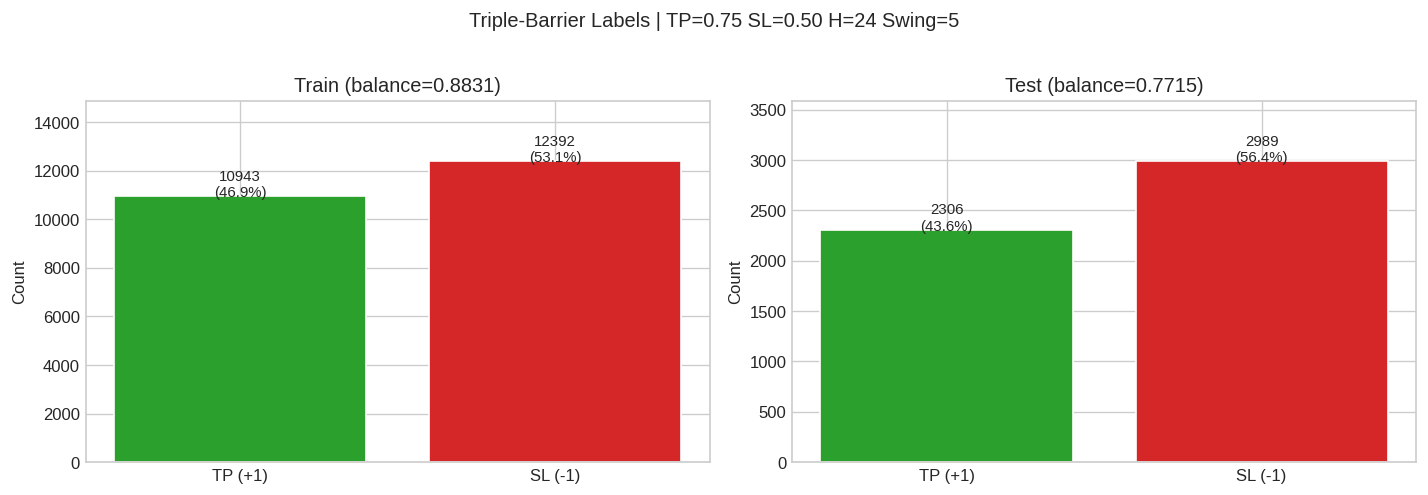

In [6]:
# Requires: §3 train, test, tp_atr, sl_atr
train_dist = summarize_label_distribution(train["label"].to_numpy())
test_dist = summarize_label_distribution(test["label"].to_numpy())

fig, axes = _track(plt.subplots(1, 2, figsize=(12, 4)))
for ax, dist, title in zip(axes, [train_dist, test_dist], ["Train", "Test"]):
    cats = ["TP (+1)", "SL (-1)"]
    vals = [dist.get(c, 0) for c in cats]
    bars = ax.bar(cats, vals, color=["#2ca02c", "#d62728"], edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f"{v}\n({v / dist['total'] * 100:.1f}%)", ha="center", fontsize=9)
    ax.set_title(f"{title} (balance={dist['balance_ratio']:.4f})")
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(vals) * 1.2)

fig.suptitle(f"Triple-Barrier Labels | TP={tp_atr:.2f} SL={sl_atr:.2f} H={LABELING_HORIZON} Swing={SWING_WINDOW}",
             y=1.02)
fig.tight_layout()
plt.show()

## 5. Feature Visualizations

### 5.1 Fractional Differencing

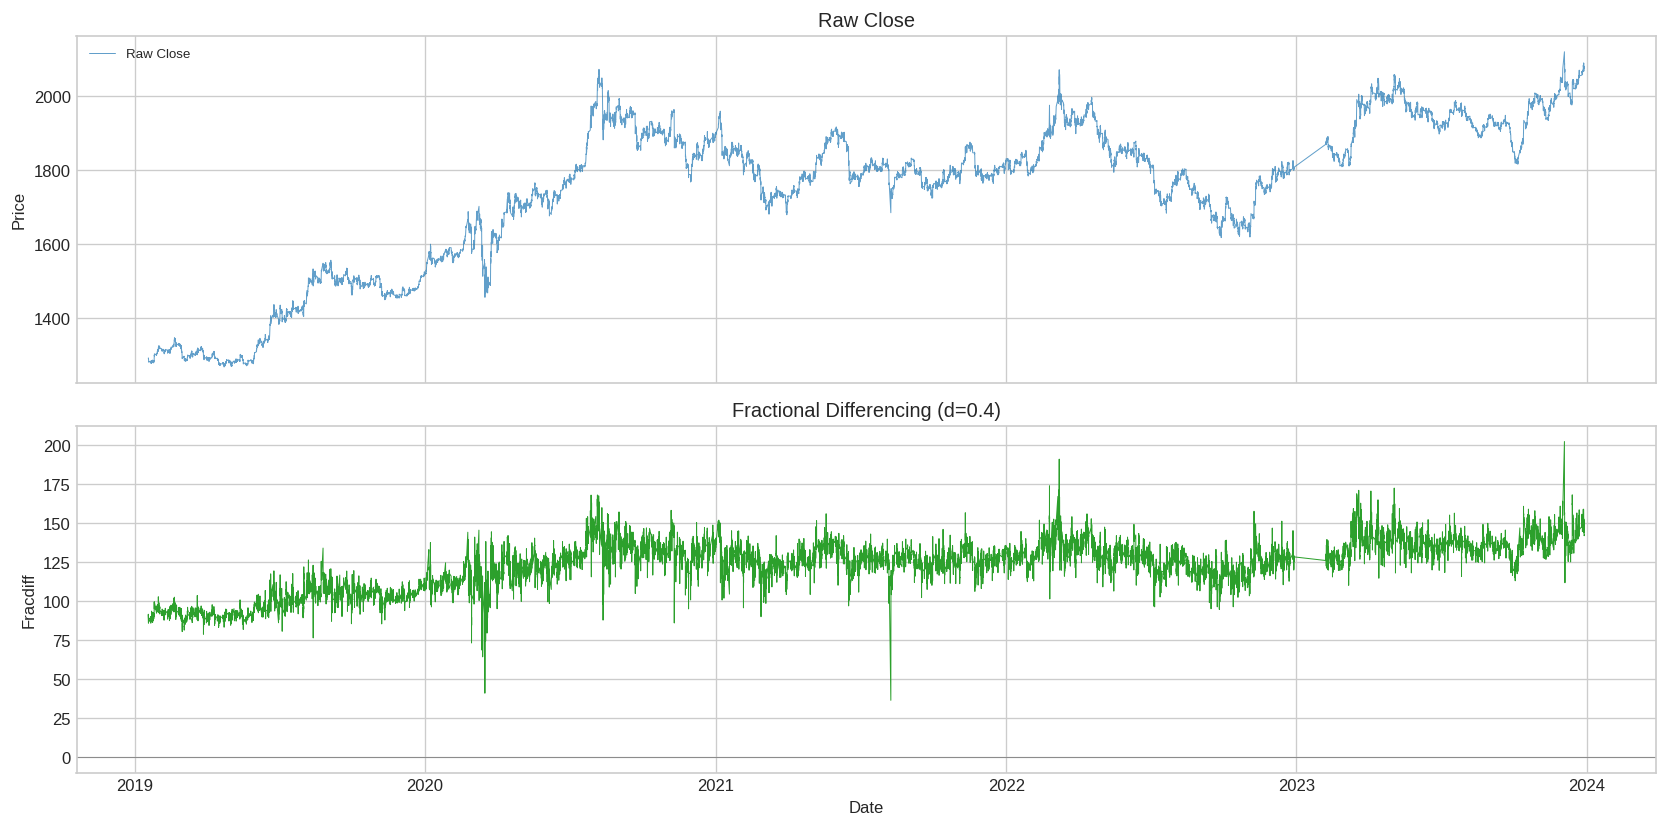

In [7]:
# Requires: §3 dataset_pdf, FRACTIONAL_D
fig, axes = _track(plt.subplots(2, 1, figsize=(14, 7), sharex=True))
axes[0].plot(dataset_pdf.index, dataset_pdf["close"], color="#1f77b4", lw=0.6, alpha=0.7, label="Raw Close")
axes[0].set_title("Raw Close")
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Price")

axes[1].plot(dataset_pdf.index, dataset_pdf["close_fracdiff"], color="#2ca02c", lw=0.6)
axes[1].set_title(f"Fractional Differencing (d={FRACTIONAL_D})")
axes[1].set_ylabel("Fracdiff")
axes[1].set_xlabel("Date")
axes[1].axhline(0, color="gray", lw=0.5)
fig.tight_layout()

### 5.2 ADF Stationarity Test

ADF Test: Raw Close
  ADF Statistic : -1.8584
  p-value       : 0.351886
  Critical 5%   : -2.8616
  Conclusion    : NON-STATIONARY (p >= 0.05)

ADF Test: Fractionally Differenced Close (d=0.4)
  ADF Statistic : -4.5514
  p-value       : 0.000159
  Critical 5%   : -2.8616
  Conclusion    : Stationary

    d |   ADF Stat |    p-value | Stationary?
------------------------------------------------------------
  0.0 |    -1.8584 |   0.351886 |          No
  0.1 |    -3.2702 |   0.016265 |         Yes
  0.2 |    -4.4596 |   0.000232 |         Yes
  0.3 |    -6.1126 |   0.000000 |         Yes
  0.4 |    -7.5498 |   0.000000 |         Yes <<<
  0.5 |    -9.6024 |   0.000000 |         Yes
  0.6 |   -11.9501 |   0.000000 |         Yes
  0.7 |   -14.6390 |   0.000000 |         Yes
  0.8 |   -18.0824 |   0.000000 |         Yes
  0.9 |   -21.3369 |   0.000000 |         Yes
  1.0 |   -31.5753 |   0.000000 |         Yes

Minimum d for stationarity (5% level): 0.1
Chosen d=0.4: PASSES ADF at 5% level

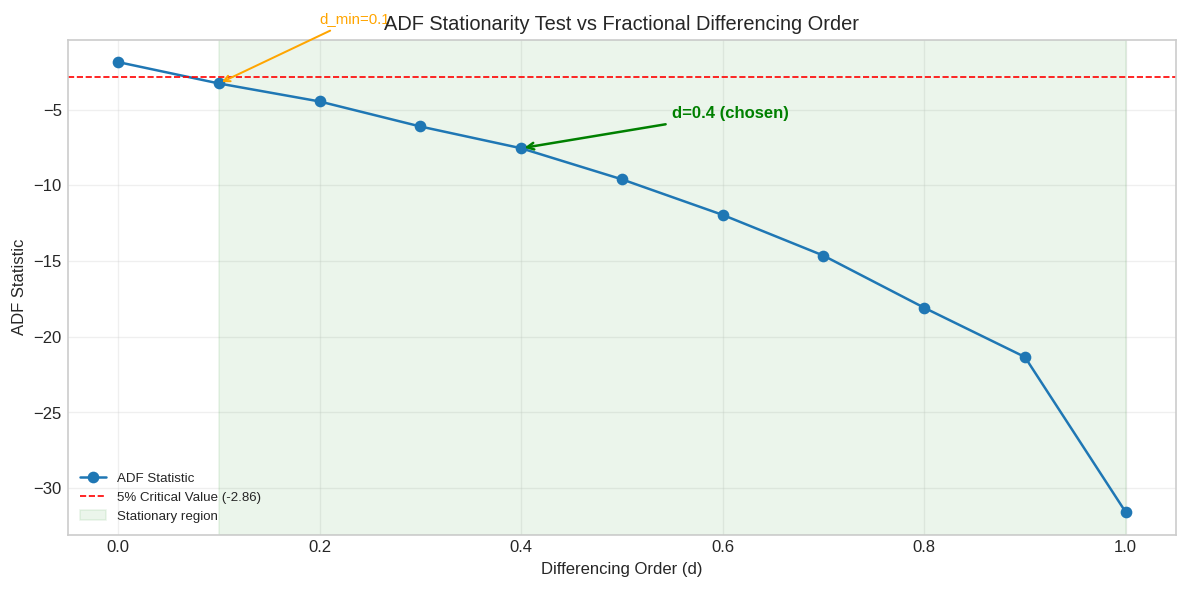

In [8]:
# Requires: §3 featured, FRACTIONAL_D
from statsmodels.tsa.stattools import adfuller
from src.features import compute_fractional_diff_weights, apply_fractional_diff

close_raw = featured["close"].to_numpy()
close_fd = featured["close_fracdiff"].to_numpy()

# --- ADF on raw close ---
raw_clean = close_raw[~np.isnan(close_raw)]
adf_raw = adfuller(raw_clean, autolag="AIC")
print("=" * 60)
print("ADF Test: Raw Close")
print(f"  ADF Statistic : {adf_raw[0]:.4f}")
print(f"  p-value       : {adf_raw[1]:.6f}")
print(f"  Critical 5%   : {adf_raw[4]['5%']:.4f}")
print(f"  Conclusion    : {'Stationary' if adf_raw[1] < 0.05 else 'NON-STATIONARY (p >= 0.05)'}")
print()

# --- ADF on close_fracdiff ---
fd_clean = close_fd[~np.isnan(close_fd)]
adf_fd = adfuller(fd_clean, autolag="AIC")
print("=" * 60)
print(f"ADF Test: Fractionally Differenced Close (d={FRACTIONAL_D})")
print(f"  ADF Statistic : {adf_fd[0]:.4f}")
print(f"  p-value       : {adf_fd[1]:.6f}")
print(f"  Critical 5%   : {adf_fd[4]['5%']:.4f}")
print(f"  Conclusion    : {'Stationary' if adf_fd[1] < 0.05 else 'NON-STATIONARY (p >= 0.05)'}")
print()

# --- Scan d in [0.0, 0.1, ..., 1.0] ---
d_values = np.arange(0.0, 1.1, 0.1)
scan_results = []
for d in d_values:
    weights = compute_fractional_diff_weights(d, threshold=1e-5)
    frac_series = apply_fractional_diff(close_raw, weights)
    clean = frac_series[~np.isnan(frac_series)]
    if len(clean) < 20:
        scan_results.append((d, np.nan, np.nan))
        continue
    res = adfuller(clean, autolag="AIC")
    scan_results.append((d, res[0], res[1]))

d_min = None
for d_val, stat, p in scan_results:
    if p < 0.05 and d_min is None:
        d_min = d_val
        break

# --- Plot ADF statistic vs d ---
fig, ax = _track(plt.subplots(figsize=(10, 5)))
ds = [r[0] for r in scan_results]
stats = [r[1] for r in scan_results]

ax.plot(ds, stats, "o-", color="#1f77b4", lw=1.5, markersize=6, label="ADF Statistic")
crit_5 = adf_fd[4]["5%"]
ax.axhline(crit_5, color="red", ls="--", lw=1, label=f"5% Critical Value ({crit_5:.2f})")

idx_04 = next(i for i, r in enumerate(scan_results) if abs(r[0] - FRACTIONAL_D) < 1e-9)
ax.annotate(
    f"d={FRACTIONAL_D} (chosen)",
    xy=(FRACTIONAL_D, stats[idx_04]),
    xytext=(FRACTIONAL_D + 0.15, stats[idx_04] + 2),
    arrowprops=dict(arrowstyle="->", color="green", lw=1.5),
    fontsize=10, fontweight="bold", color="green",
)

if d_min is not None:
    idx_min = next(i for i, r in enumerate(scan_results) if abs(r[0] - d_min) < 1e-9)
    ax.annotate(
        f"d_min={d_min:.1f}",
        xy=(d_min, stats[idx_min]),
        xytext=(d_min + 0.1, stats[idx_min] + 4),
        arrowprops=dict(arrowstyle="->", color="orange", lw=1.2),
        fontsize=9, color="orange",
    )
    ax.axvspan(d_min, 1.0, alpha=0.08, color="green", label="Stationary region")

ax.set_xlabel("Differencing Order (d)")
ax.set_ylabel("ADF Statistic")
ax.set_title("ADF Stationarity Test vs Fractional Differencing Order")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()

# --- Print formatted table ---
print("=" * 60)
print(f"{'d':>5s} | {'ADF Stat':>10s} | {'p-value':>10s} | {'Stationary?':>11s}")
print("-" * 60)
for d_val, stat, p in scan_results:
    stationary = "Yes" if p < 0.05 else "No"
    marker = " <<<" if abs(d_val - FRACTIONAL_D) < 1e-9 else ""
    print(f"{d_val:5.1f} | {stat:10.4f} | {p:10.6f} | {stationary:>11s}{marker}")
print("=" * 60)
print()
if d_min is not None:
    print(f"Minimum d for stationarity (5% level): {d_min:.1f}")
    passes = any(abs(r[0]-FRACTIONAL_D)<1e-9 and r[2]<0.05 for r in scan_results)
    print(f"Chosen d={FRACTIONAL_D}: {'PASSES' if passes else 'FAILS'} ADF at 5% level")
    print(f"Rationale: While d={d_min:.1f} is the minimum that passes ADF, d={FRACTIONAL_D} provides")
    print(f"           stronger stationarity (more negative ADF stat) with a comfortable margin,")
    print(f"           while still preserving substantial memory from the original series.")
else:
    print("No d value achieves stationarity at the 5% level.")

### 5.3 Technical Indicators

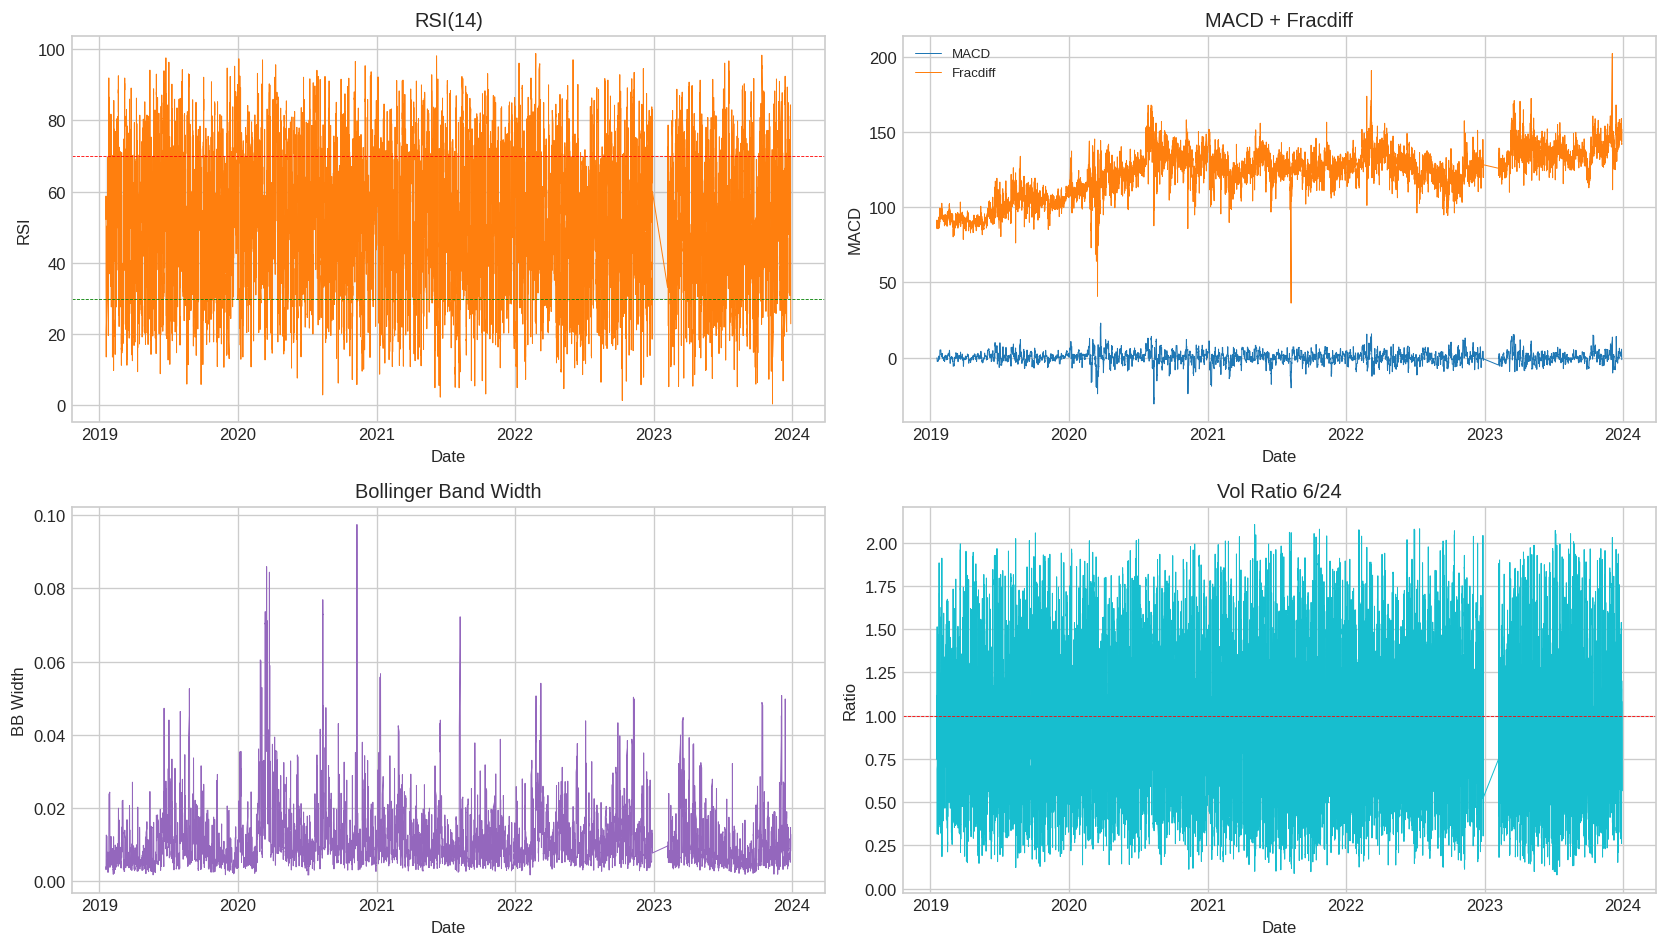

In [9]:
# Requires: §3 dataset_pdf
fig, axes = _track(plt.subplots(2, 2, figsize=(14, 8)))

axes[0, 0].plot(dataset_pdf.index, dataset_pdf["rsi_14"], color="#ff7f0e", lw=0.6)
axes[0, 0].axhline(70, color="red", lw=0.5, ls="--")
axes[0, 0].axhline(30, color="green", lw=0.5, ls="--")
axes[0, 0].fill_between(dataset_pdf.index, 30, 70, alpha=0.1, color="gray")
axes[0, 0].set_title("RSI(14)")
axes[0, 0].set_ylabel("RSI")

axes[0, 1].plot(dataset_pdf.index, dataset_pdf["macd"], color="#1f77b4", lw=0.6, label="MACD")
axes[0, 1].plot(dataset_pdf.index, dataset_pdf["close_fracdiff"], color="#ff7f0e", lw=0.6, label="Fracdiff")
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_title("MACD + Fracdiff")
axes[0, 1].set_ylabel("MACD")

axes[1, 0].plot(dataset_pdf.index, dataset_pdf["bb_width"], color="#9467bd", lw=0.6)
axes[1, 0].set_title("Bollinger Band Width")
axes[1, 0].set_ylabel("BB Width")

axes[1, 1].plot(dataset_pdf.index, dataset_pdf["vol_ratio_6_24"], color="#17becf", lw=0.6)
axes[1, 1].axhline(1.0, color="red", lw=0.5, ls="--")
axes[1, 1].set_title("Vol Ratio 6/24")
axes[1, 1].set_ylabel("Ratio")

for ax in axes.flat:
    ax.set_xlabel("Date")
fig.tight_layout()

### 5.4 Feature Correlation

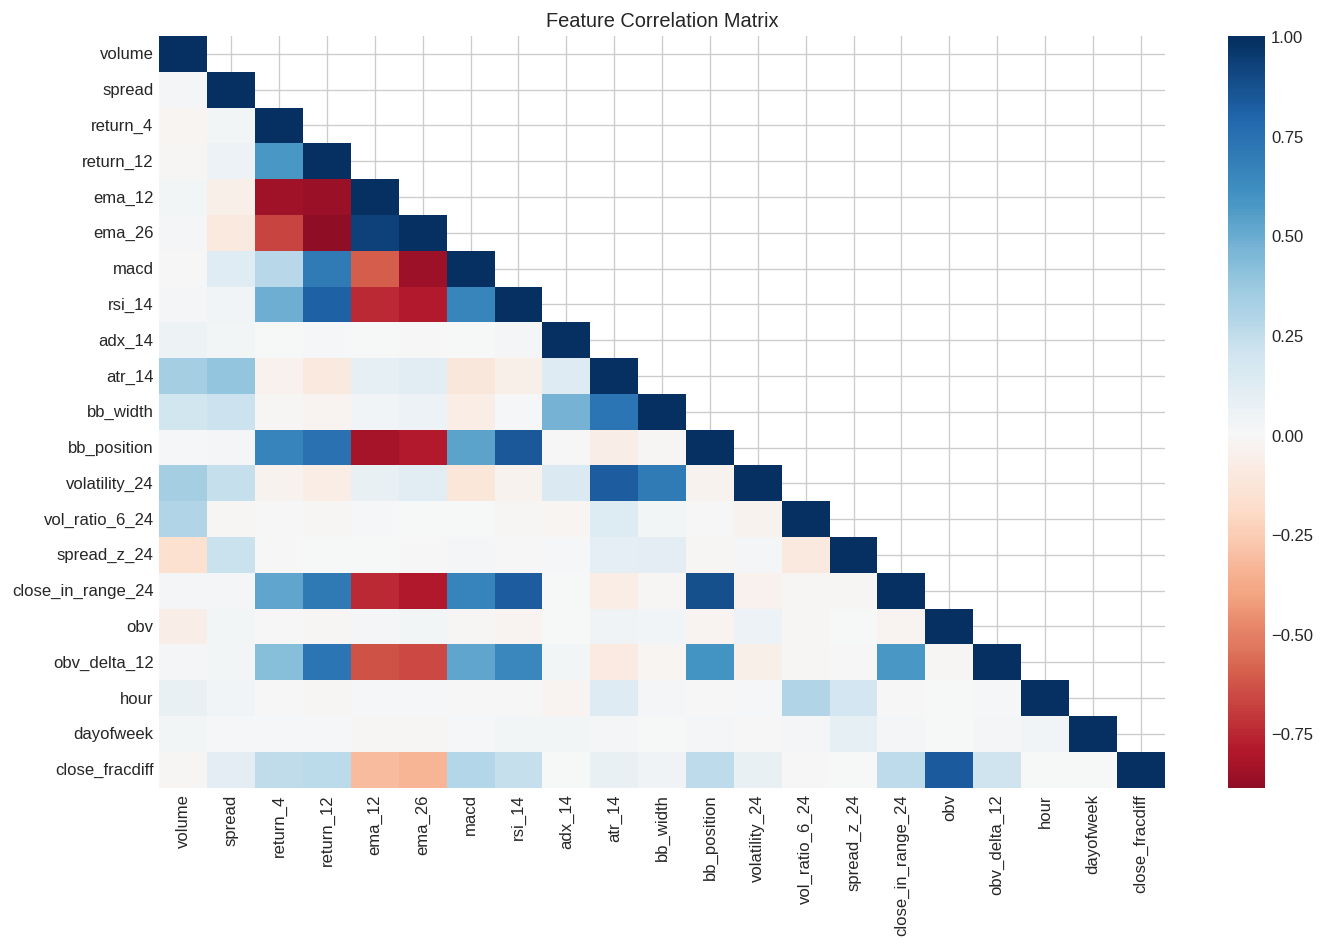

In [10]:
# Requires: §3 dataset_pdf, features
fig, ax = _track(plt.subplots(figsize=(12, 8)))
corr_cols = [c for c in features if c in dataset_pdf.columns]
corr = dataset_pdf[corr_cols].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1),
            cmap="RdBu", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
fig.tight_layout()
plt.show()

### 5.5 Feature Distributions by Label Class

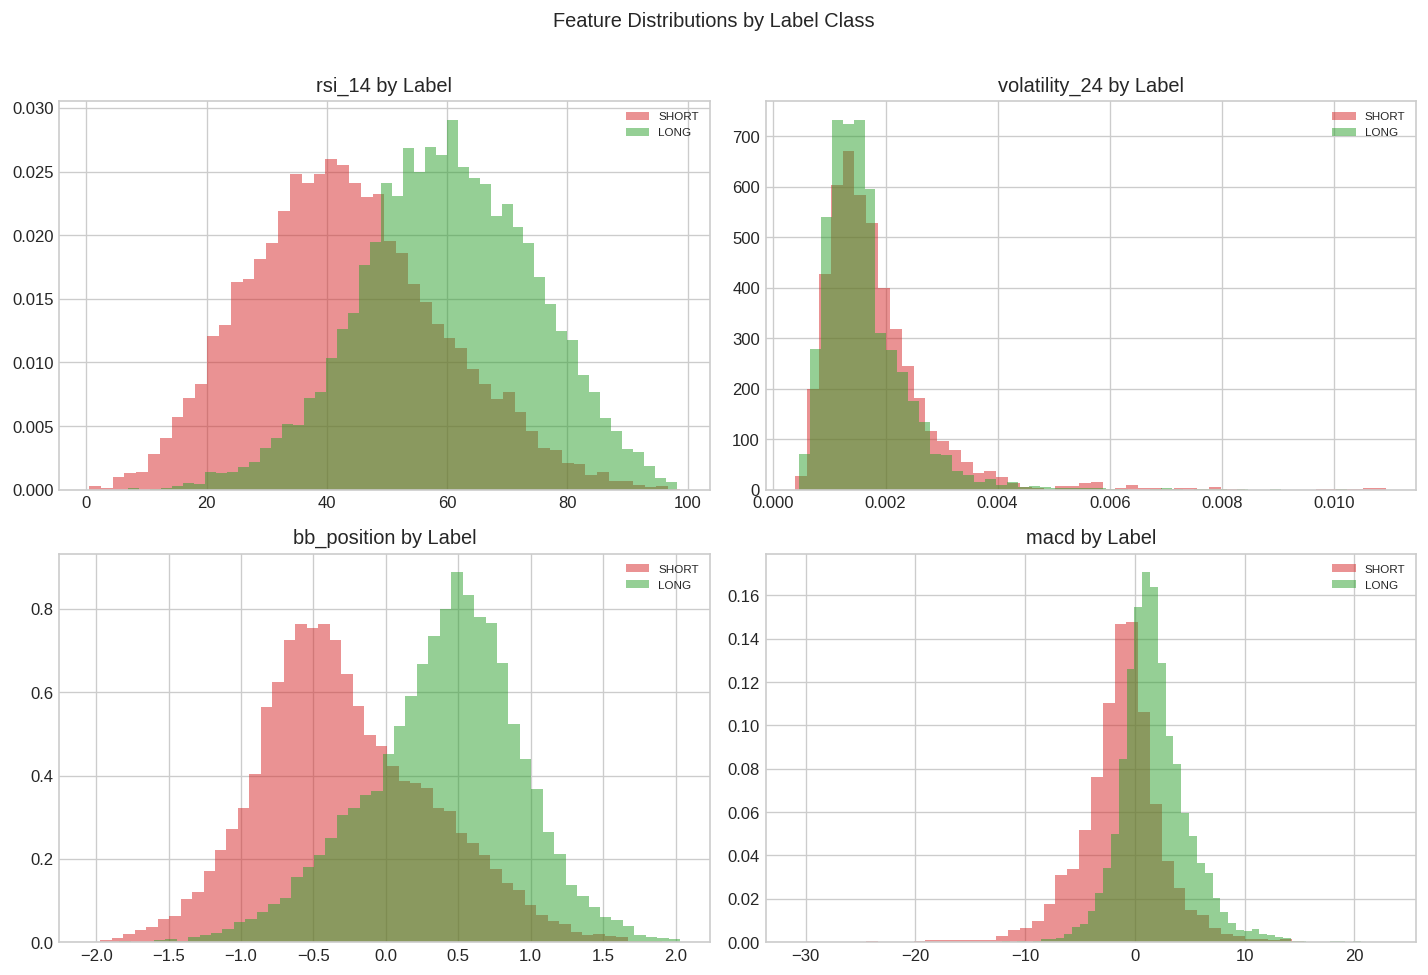

In [11]:
# Requires: §3 dataset_pdf, §1 PALETTE, LABEL_NAMES
fig, axes = _track(plt.subplots(2, 2, figsize=(12, 8)))
for ax, col in zip(axes.flat, ["rsi_14", "volatility_24", "bb_position", "macd"]):
    for lv in (-1, 1):
        sub = dataset_pdf.loc[dataset_pdf["label"] == lv, col].dropna()
        ax.hist(sub, bins=50, alpha=0.5, color=PALETTE[lv],
                label=LABEL_NAMES[lv], density=True)
    ax.set_title(f"{col} by Label")
    ax.legend(fontsize=7)
fig.suptitle("Feature Distributions by Label Class", y=1.01)
fig.tight_layout()
plt.show()

## 6. Cross-Validation

### 6.1 Purged Embargo CV Splits

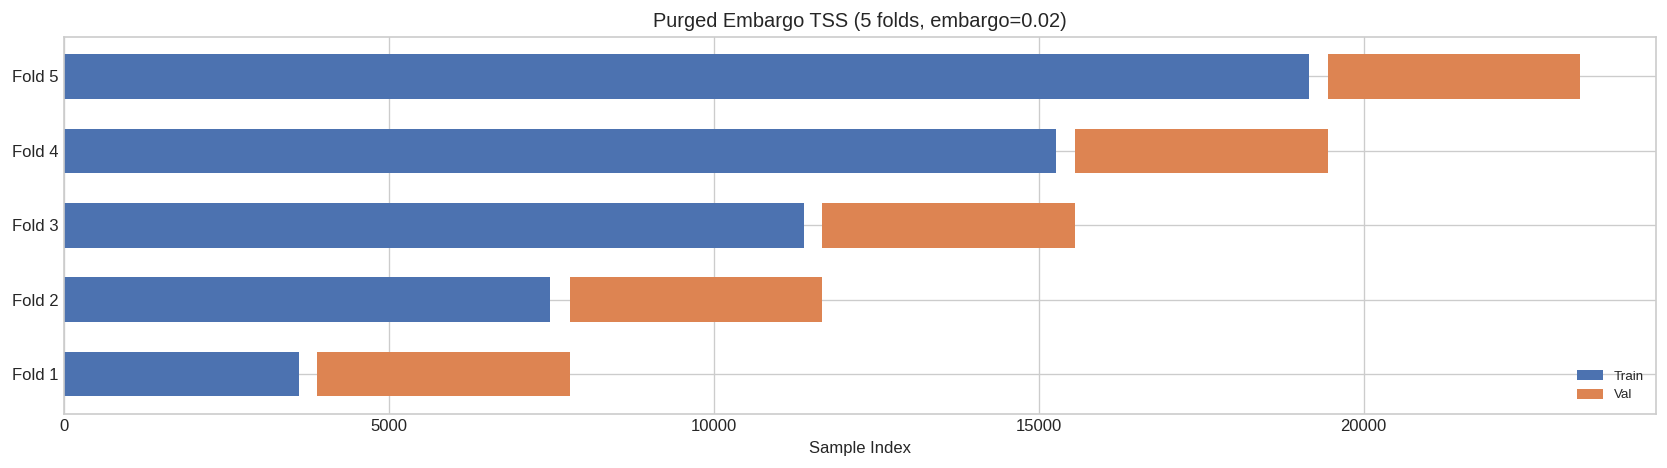

In [12]:
# Requires: §3 train, features, §1 CV_SPLITS, EMBARGO_PCT
cv = PurgedEmbargoTimeSeriesSplit(CV_SPLITS, EMBARGO_PCT)

fig, ax = _track(plt.subplots(figsize=(14, 4)))
for fold, (tr, va) in enumerate(cv.split(train[features], train["event_end"])):
    ax.barh(fold, len(tr), left=tr[0], color="#4c72b0", height=0.6,
            label="Train" if fold == 0 else "")
    ax.barh(fold, len(va), left=va[0], color="#dd8452", height=0.6,
            label="Val" if fold == 0 else "")

ax.set_yticks(range(CV_SPLITS), [f"Fold {i+1}" for i in range(CV_SPLITS)])
ax.set_xlabel("Sample Index")
ax.set_title(f"Purged Embargo TSS ({CV_SPLITS} folds, embargo={EMBARGO_PCT})")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

### 6.2 Learning Curve

Train vs validation F1 macro across sample sizes. LightGBM proxy on raw features with purged-embargo CV.

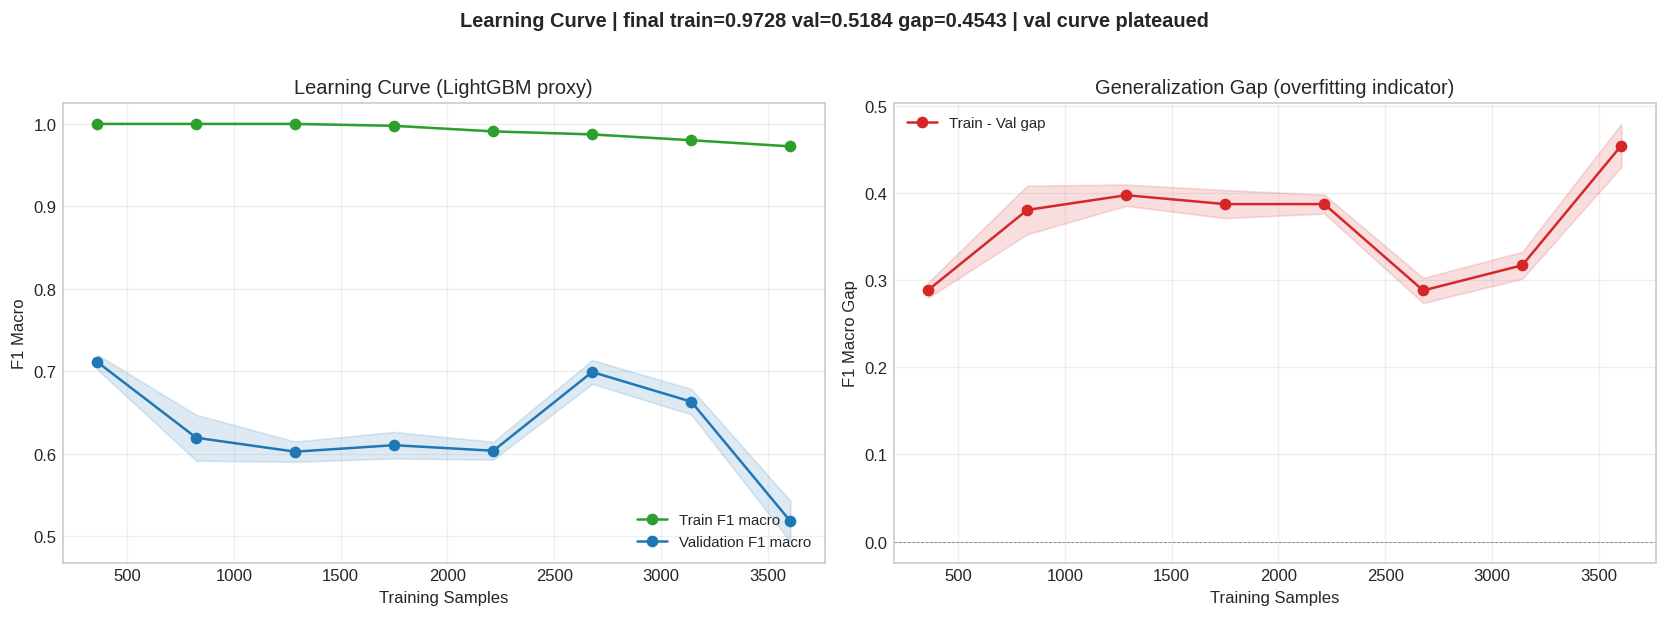

In [13]:
# Requires: §3 train, features, §6.1 cv, §1 RANDOM_STATE
from lightgbm import LGBMClassifier
from sklearn.model_selection import learning_curve

lc_estimator = LGBMClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=RANDOM_STATE, verbose=-1,
)

X_lc = train[features].to_pandas()
y_lc = train['label'].to_numpy()
event_end_lc = train['event_end'].to_pandas()
lc_splits = list(cv.split(X_lc, event_end_lc))

train_sizes_abs, train_scores, val_scores = learning_curve(
    lc_estimator, X_lc, y_lc,
    cv=lc_splits, scoring='f1_macro', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=RANDOM_STATE,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
gap = train_mean - val_mean

fig, axes = _track(plt.subplots(1, 2, figsize=(14, 5)))

axes[0].plot(train_sizes_abs, train_mean, 'o-', color='#2ca02c', label='Train F1 macro')
axes[0].fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='#2ca02c')
axes[0].plot(train_sizes_abs, val_mean, 'o-', color='#1f77b4', label='Validation F1 macro')
axes[0].fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='#1f77b4')
axes[0].set_xlabel('Training Samples')
axes[0].set_ylabel('F1 Macro')
axes[0].set_title('Learning Curve (LightGBM proxy)')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].plot(train_sizes_abs, gap, 'o-', color='#d62728', label='Train - Val gap')
axes[1].fill_between(train_sizes_abs,
                     gap - (train_std + val_std),
                     gap + (train_std + val_std),
                     alpha=0.15, color='#d62728')
axes[1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].set_xlabel('Training Samples')
axes[1].set_ylabel('F1 Macro Gap')
axes[1].set_title('Generalization Gap (overfitting indicator)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

final_train = train_mean[-1]
final_val = val_mean[-1]
final_gap = gap[-1]
trend = 'still rising' if val_mean[-1] > val_mean[-2] else 'plateaued'
fig.suptitle(f'Learning Curve | final train={final_train:.4f} val={final_val:.4f} '
             f'gap={final_gap:.4f} | val curve {trend}',
             y=1.02, fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

## 7. Model Training

In [14]:
# Requires: §3 train, features, §1 config + hyperparams
if need('model'):
    with _section("model_training"):
        model = HybridStackingSignalClassifier(
            n_splits=CV_SPLITS, embargo_pct=EMBARGO_PCT,
            min_oof_f1=MIN_OOF_F1, confidence_threshold=CONFIDENCE_THRESHOLD,
            use_meta_labeling=USE_META_LABELING,
            meta_label_threshold=META_LABEL_THRESHOLD,
            short_meta_label_threshold=SHORT_META_LABEL_THRESHOLD,
            adx_threshold=ADX_THRESHOLD, bb_width_min_mult=BB_WIDTH_MIN_MULT,
            long_only=config.long_only,
            trend_filter_enabled=TREND_FILTER_ENABLED,
            trend_ema_period=TREND_EMA_PERIOD,
            random_state=RANDOM_STATE,
        )
        model.fit(train[features], train["label"], train["event_end"])
        print("Training complete.")
    NOTEBOOK_STATE['model'] = True

Training complete.


### 7.1 Hyperparameter Summary

In [15]:
# Hyperparameter table for thesis
hp_data = {
    "Parameter": [
        "Timeframe", "Fractional d", "CV splits", "Embargo %", "Purge %",
        "Test size", "Min OOF F1", "Confidence threshold",
        "Meta-labeling", "Meta-label threshold", "Short meta-label threshold",
        "ADX threshold", "BB width min mult", "Swing window", "Labeling horizon",
        "Trend filter", "Trend EMA period",
        "Backtest TP range", "Backtest SL range", "Min hold values",
        "Leverage", "Contract size", "Initial balance",
        "Random state",
    ],
    "Value": [
        TIMEFRAME, str(FRACTIONAL_D), str(CV_SPLITS), f"{EMBARGO_PCT:.0%}", f"{PURGE_PCT:.0%}",
        f"{TEST_SIZE:.0%}", str(MIN_OOF_F1), str(CONFIDENCE_THRESHOLD),
        str(USE_META_LABELING), str(META_LABEL_THRESHOLD), str(SHORT_META_LABEL_THRESHOLD),
        str(ADX_THRESHOLD), str(BB_WIDTH_MIN_MULT), str(SWING_WINDOW), str(LABELING_HORIZON),
        str(TREND_FILTER_ENABLED), str(TREND_EMA_PERIOD),
        str(TUNE_TP_RANGE_BT), str(TUNE_SL_RANGE_BT), str(TUNE_HOLD_VALUES),
        str(LEVERAGE), str(CONTRACT_SIZE), f"${INITIAL_BALANCE:,.0f}",
        str(RANDOM_STATE),
    ],
}
hp_df = pd.DataFrame(hp_data)
print("=== Bảng 4.1: Cấu hình siêu tham số ===")
print(hp_df.to_string(index=False))

=== Bảng 4.1: Cấu hình siêu tham số ===
                 Parameter            Value
                 Timeframe               1h
              Fractional d              0.4
                 CV splits                5
                 Embargo %               2%
                   Purge %               2%
                 Test size              20%
                Min OOF F1              0.5
      Confidence threshold             0.45
             Meta-labeling             True
      Meta-label threshold             0.55
Short meta-label threshold             0.55
             ADX threshold             20.0
         BB width min mult              1.2
              Swing window                5
          Labeling horizon               24
              Trend filter             True
          Trend EMA period               89
         Backtest TP range (3.0, 15.0, 1.0)
         Backtest SL range (3.0, 15.0, 1.0)
           Min hold values   [6, 8, 12, 16]
                  Leverage          

## 8. Model Evaluation

### 8.1 OOF Scores & Active Models

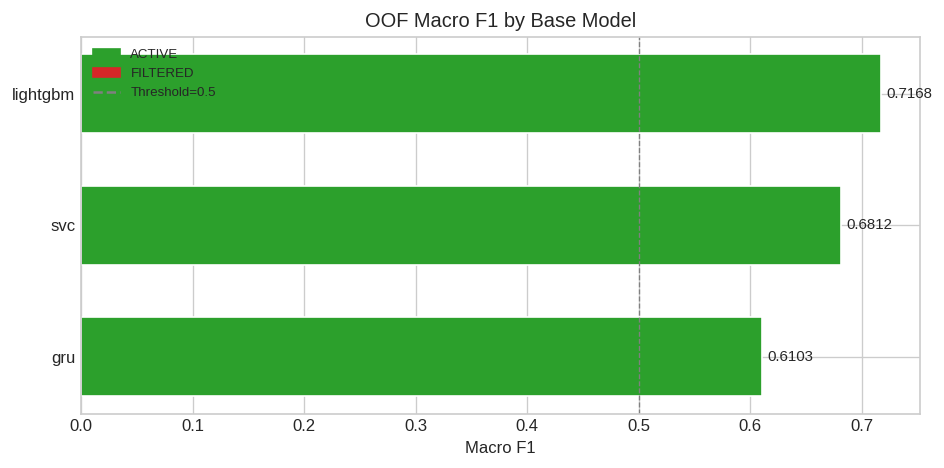

Active: 3 / 3

   Model OOF F1 Status
lightgbm 0.7168 ACTIVE
     svc 0.6812 ACTIVE
     gru 0.6103 ACTIVE


In [16]:
# Requires: §7 model, §1 MIN_OOF_F1
scores = pd.Series(model.oof_scores_).sort_values()
colors = ["#2ca02c" if n in model.active_model_names_ else "#d62728" for n in scores.index]

fig, ax = _track(plt.subplots(figsize=(8, 4)))
bars = ax.barh(scores.index, scores.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(MIN_OOF_F1, color="gray", ls="--", lw=0.8, label=f"Min OOF F1={MIN_OOF_F1}")
for b, v in zip(bars, scores.values):
    ax.text(v + 0.005, b.get_y() + b.get_height() / 2, f"{v:.4f}", va="center", fontsize=9)

ax.legend(handles=[
    Patch(color="#2ca02c", label="ACTIVE"),
    Patch(color="#d62728", label="FILTERED"),
    plt.Line2D([0], [0], color="gray", ls="--", label=f"Threshold={MIN_OOF_F1}"),
], fontsize=8)
ax.set_title("OOF Macro F1 by Base Model")
ax.set_xlabel("Macro F1")
fig.tight_layout()
plt.show()

# --- Model status table ---
active_df = pd.DataFrame({
    "Model": list(model.oof_scores_.keys()),
    "OOF F1": [f"{v:.4f}" for v in model.oof_scores_.values()],
    "Status": ["ACTIVE" if n in model.active_model_names_ else "FILTERED" for n in model.oof_scores_],
}).sort_values("OOF F1", ascending=False)

print(f"Active: {len(model.active_model_names_)} / {len(model.oof_scores_)}\n")
print(active_df.to_string(index=False))

### 8.2 Test Set Evaluation

In [17]:
# Requires: §7 model, §3 test, features, §1 LABELS
if need('predictions'):
    predictions = model.predict(test[features])
    # Note: positions_raw uses default min_hold=4, NOT the tuned value.
    # Actual backtest positions are computed in §9 with tuned params.
    positions_raw = model.predict_positions(test[features], close_prices=test["close"].to_numpy(), skip_min_hold=True)
    pred_proba = model.predict_proba(test[features])
    y_true = test["label"].to_numpy()
    proba_labels = model.label_encoder.inverse_transform(model.meta_model.classes_)
    NOTEBOOK_STATE['predictions'] = True

print(f"Accuracy: {accuracy_score(y_true, predictions):.4f}")
print(f"F1 macro: {f1_score(y_true, predictions, average='macro', zero_division=0):.4f}")
print(classification_report(y_true, predictions, zero_division=0))

Accuracy: 0.7343
F1 macro: 0.7331
              precision    recall  f1-score   support

        -1.0       0.80      0.71      0.75      2989
         1.0       0.67      0.77      0.72      2306

    accuracy                           0.73      5295
   macro avg       0.73      0.74      0.73      5295
weighted avg       0.74      0.73      0.74      5295



### 8.3 Confusion Matrix

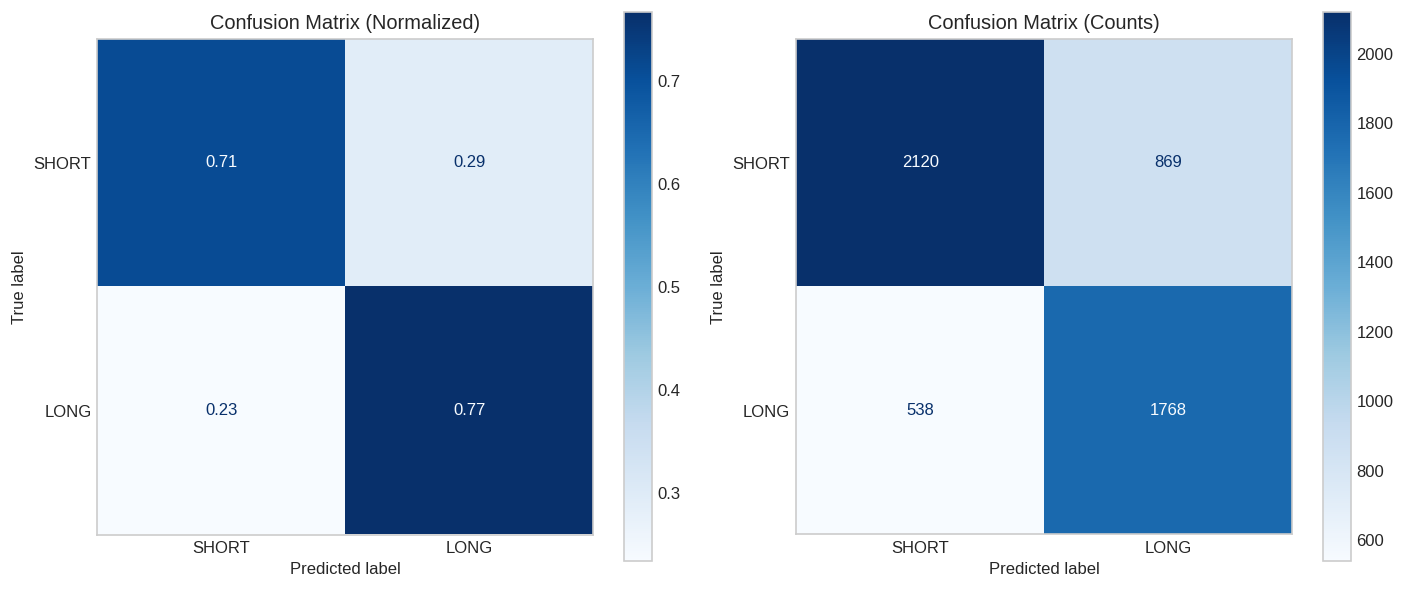

In [18]:
# Requires: §8.2 y_true, predictions, §1 LABEL_ORDER, LABEL_NAMES
fig, axes = _track(plt.subplots(1, 2, figsize=(12, 5)))
for ax, norm, suffix in zip(axes, ["true", None], ["(Normalized)", "(Counts)"]):
    ConfusionMatrixDisplay.from_predictions(
        y_true, predictions, labels=LABEL_ORDER,
        display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
        cmap="Blues", ax=ax, normalize=norm,
    )
    ax.set_title(f"Confusion Matrix {suffix}")
    ax.grid(False)
fig.tight_layout()
plt.show()

### 8.4 Classification Diagnostics

ROC, Precision-Recall, Calibration & per-class metrics on test set.

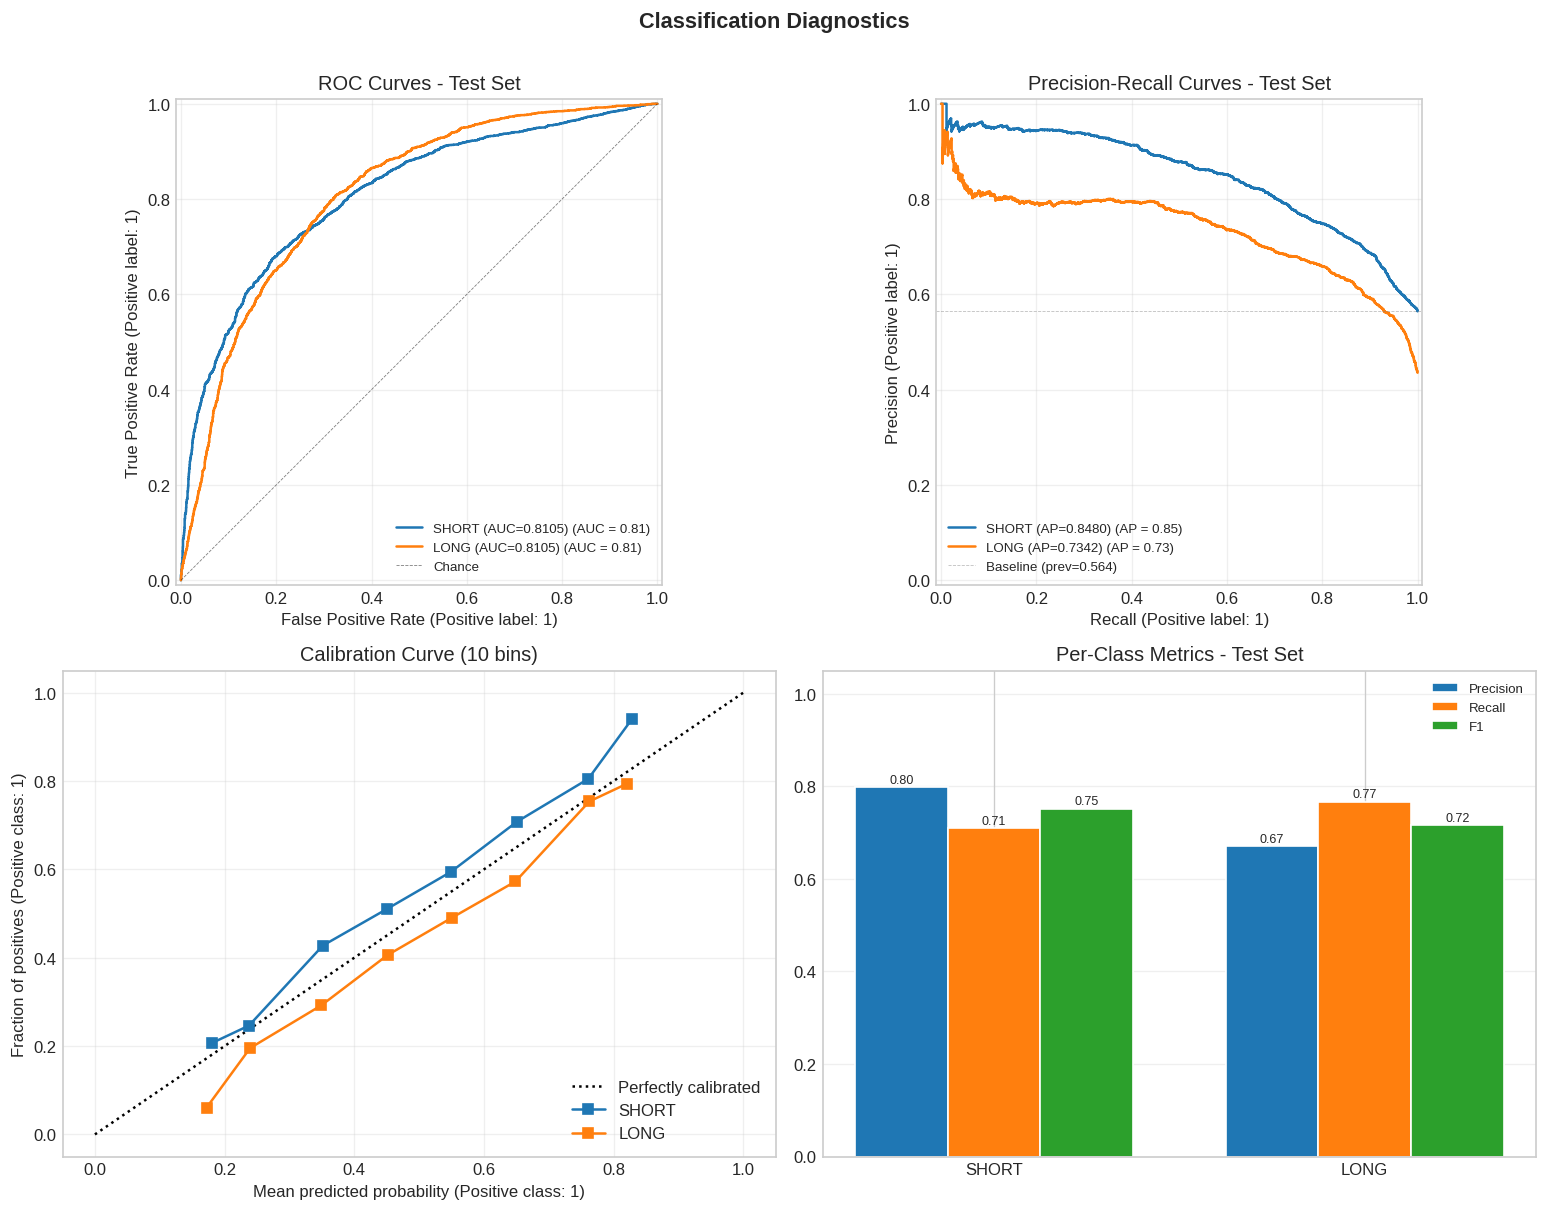

In [19]:
# Requires: §8.2 y_true, pred_proba, proba_labels, predictions, §1 LABELS, LABEL_ORDER, LABEL_NAMES
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (PrecisionRecallDisplay,
                             RocCurveDisplay, average_precision_score,
                             roc_auc_score)

y_test_bin = {lv: (y_true == lv).astype(int) for lv in LABELS}
class_to_col = {proba_labels[i]: i for i in range(len(proba_labels))}

fig, axes = _track(plt.subplots(2, 2, figsize=(13, 10)))

for lv in LABELS:
    y_b = y_test_bin[lv]
    score = pred_proba[:, class_to_col[lv]]
    RocCurveDisplay.from_predictions(
        y_b, score, ax=axes[0, 0],
        name=f'{LABEL_NAMES[lv]} (AUC={roc_auc_score(y_b, score):.4f})',
        plot_chance_level=False,
    )
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=0.5, alpha=0.5, label='Chance')
axes[0, 0].set_title('ROC Curves - Test Set')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

for lv in LABELS:
    y_b = y_test_bin[lv]
    score = pred_proba[:, class_to_col[lv]]
    ap = average_precision_score(y_b, score)
    PrecisionRecallDisplay.from_predictions(
        y_b, score, ax=axes[0, 1],
        name=f'{LABEL_NAMES[lv]} (AP={ap:.4f})',
        plot_chance_level=False,
    )
baseline_prev = y_test_bin[LABELS[0]].mean()
axes[0, 1].axhline(baseline_prev, color='gray', ls='--', lw=0.5, alpha=0.5,
                   label=f'Baseline (prev={baseline_prev:.3f})')
axes[0, 1].set_title('Precision-Recall Curves - Test Set')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

cal_n_bins = 10
for lv in LABELS:
    y_b = y_test_bin[lv]
    score = pred_proba[:, class_to_col[lv]]
    CalibrationDisplay.from_predictions(
        y_b, score, ax=axes[1, 0], n_bins=cal_n_bins,
        name=LABEL_NAMES[lv],
    )
axes[1, 0].set_title(f'Calibration Curve ({cal_n_bins} bins)')
axes[1, 0].grid(alpha=0.3)

report = classification_report(y_true, predictions, labels=LABEL_ORDER,
                               output_dict=True, zero_division=0)
metrics_df = pd.DataFrame({
    str(lv): {
        'Precision': report[str(lv)]['precision'],
        'Recall': report[str(lv)]['recall'],
        'F1': report[str(lv)]['f1-score'],
    }
    for lv in LABELS
}).T

x = np.arange(len(metrics_df))
w = 0.25
for i, col in enumerate(metrics_df.columns):
    axes[1, 1].bar(x + (i - 1) * w, metrics_df[col].values, w,
                   label=col, edgecolor='white')
    for j, v in enumerate(metrics_df[col].values):
        axes[1, 1].text(x[j] + (i - 1) * w, v + 0.01, f'{v:.2f}',
                        ha='center', fontsize=7.5)
axes[1, 1].set_xticks(x, [LABEL_NAMES[int(idx)] for idx in metrics_df.index])
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title('Per-Class Metrics - Test Set')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3, axis='y')

fig.suptitle('Classification Diagnostics', y=1.005, fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

### 8.5 Prediction Accuracy Map

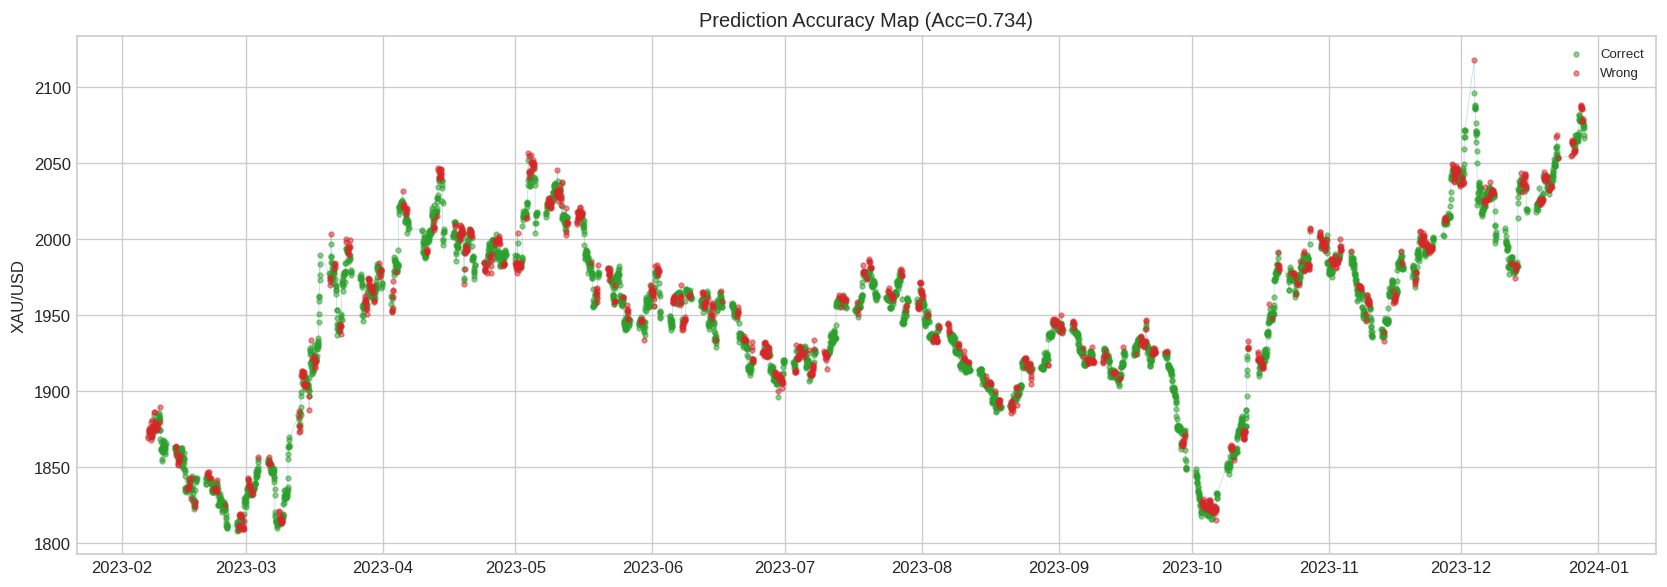

In [20]:
# Requires: §8.2 y_true, predictions, §3 test_pdf
fig, ax = _track(plt.subplots(figsize=(14, 5)))
correct = y_true == predictions
ax.scatter(test_pdf.index[correct], test_pdf["close"].iloc[correct],
           c="#2ca02c", s=8, alpha=0.5, label="Correct", zorder=3)
ax.scatter(test_pdf.index[~correct], test_pdf["close"].iloc[~correct],
           c="#d62728", s=8, alpha=0.5, label="Wrong", zorder=3)
ax.plot(test_pdf.index, test_pdf["close"], color="#1f77b4", lw=0.4, alpha=0.3)

ax.set_title(f"Prediction Accuracy Map (Acc={accuracy_score(y_true, predictions):.3f})")
ax.set_ylabel("XAU/USD")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 8.6 Feature Importance


=== FEATURE IMPORTANCE (LightGBM) ===
   1. obv                          389   11.5%  #######################
   2. volatility_24                360   10.7%  #####################
   3. close_in_range_24            276    8.2%  ################
   4. bb_width                     254    7.5%  ###############
   5. macd                         241    7.1%  ##############
   6. close_fracdiff               216    6.4%  ############
   7. adx_14                       179    5.3%  ##########
   8. atr_14                       162    4.8%  #########
   9. rsi_14                       159    4.7%  #########
  10. obv_delta_12                 140    4.1%  ########


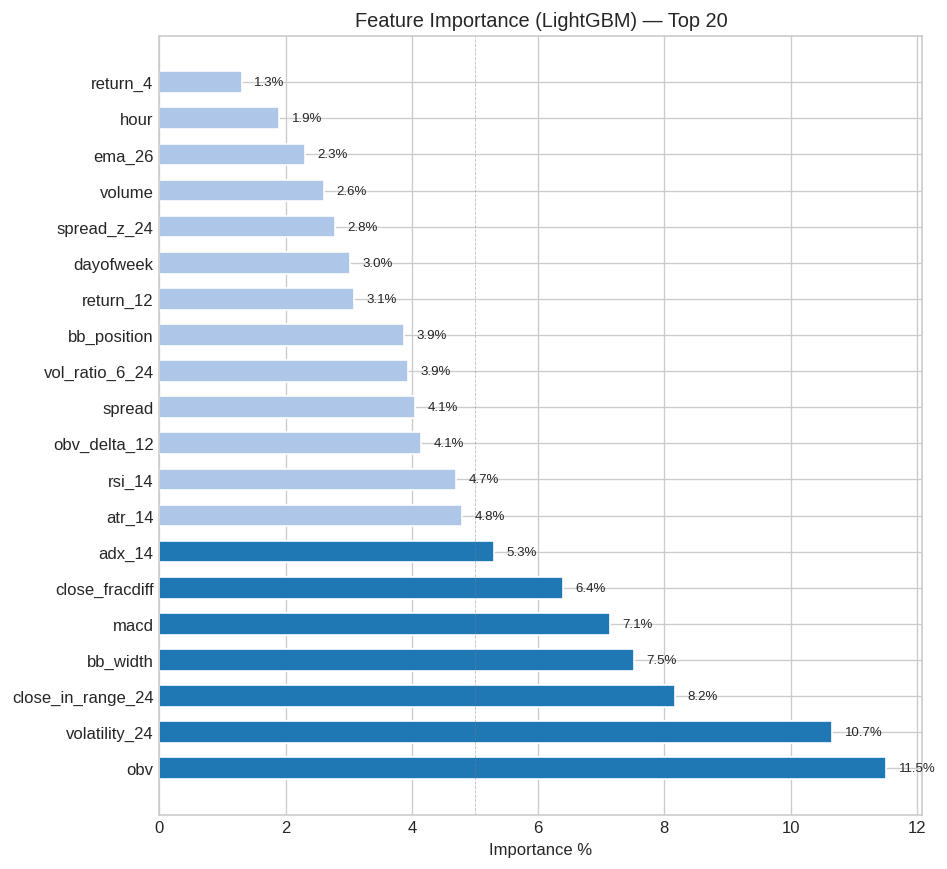

In [21]:
# Requires: §7 model, §3 features
imp_df = extract_lightgbm_feature_importance(model, features)
print_feature_importance_report(imp_df)

fig, ax = _track(plt.subplots(figsize=(8, max(6, len(imp_df) * 0.35))))
top = imp_df.head(20)
colors = ["#1f77b4" if p >= 5.0 else "#aec7e8" for p in top["pct"]]
ax.barh(top["feature"][::-1], top["pct"][::-1], color=colors[::-1],
        edgecolor="white", height=0.6)
for i, (_, row) in enumerate(top[::-1].iterrows()):
    ax.text(row["pct"] + 0.2, i, f"{row['pct']:.1f}%", va="center", fontsize=8)
ax.axvline(5.0, color="gray", lw=0.5, ls="--", alpha=0.5)
ax.invert_yaxis()
ax.set_title("Feature Importance (LightGBM) — Top 20")
ax.set_xlabel("Importance %")
fig.tight_layout()
plt.show()

### 8.7 SHAP Feature Attribution (LightGBM)

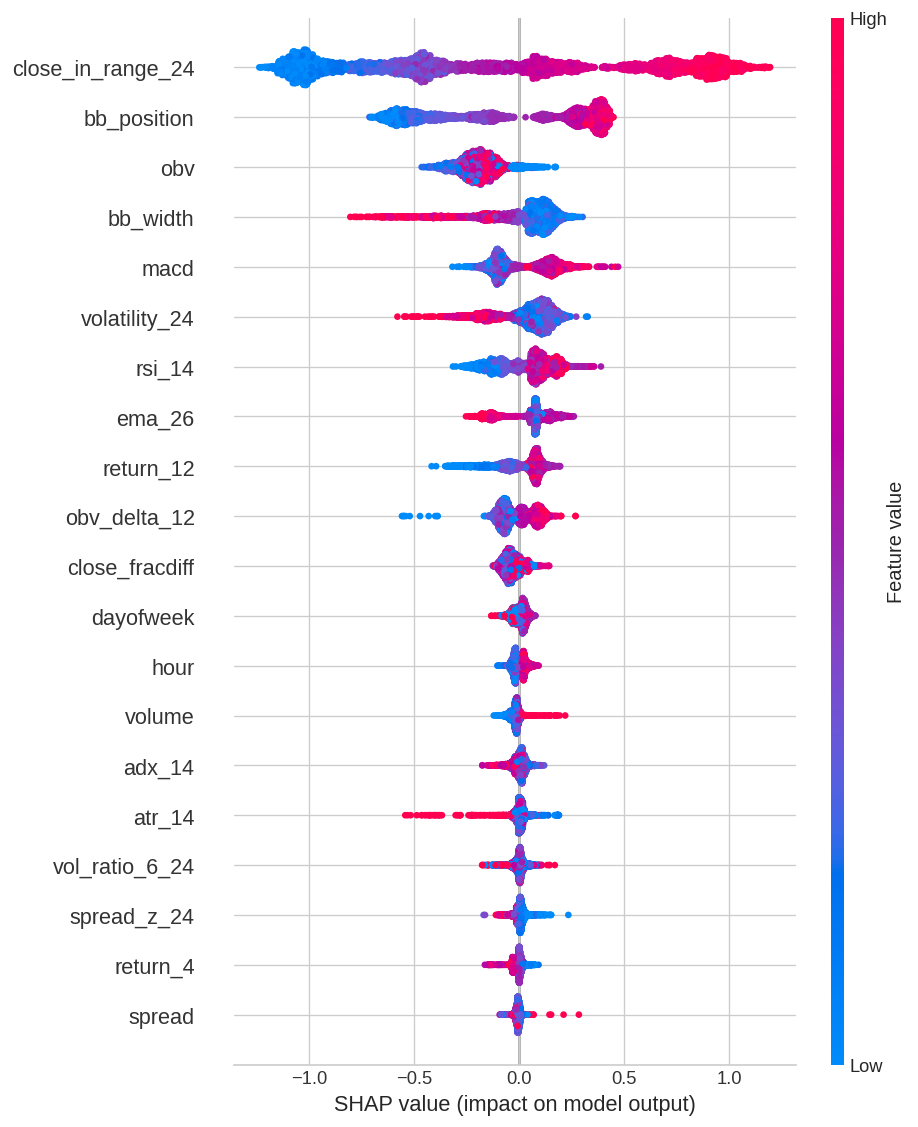

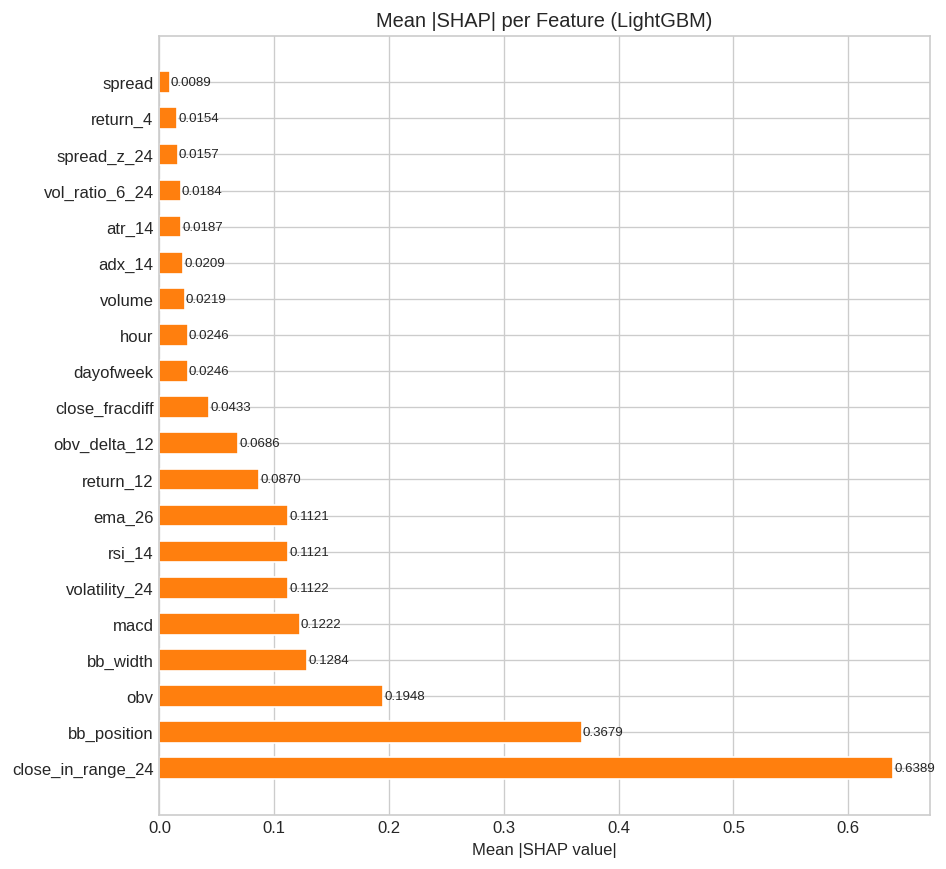


=== Feature Importance: Gain Rank vs SHAP Rank ===
          feature  gain_rank  shap_rank  rank_diff
              obv          2          3         -1
    volatility_24          3          6         -3
close_in_range_24          4          1          3
         bb_width          5          4          1
             macd          6          5          1
   close_fracdiff          7         11         -4
           adx_14          8         15         -7
           atr_14          9         16         -7
           rsi_14         10          7          3
     obv_delta_12         11         10          1
           spread         12         20         -8
   vol_ratio_6_24         13         17         -4
      bb_position         14          2         12
        return_12         15          9          6
        dayofweek         16         12          4
      spread_z_24         17         18         -1
           volume         18         14          4
           ema_26         19  

In [22]:
# Requires: §7 model, §3 test, features, §8.6 imp_df, §1 RANDOM_STATE
# FIX: import Pipeline from sklearn.pipeline, use .iloc for pandas DataFrames
import shap
from sklearn.pipeline import Pipeline

with _section("shap_analysis"):
    # Extract trained LightGBM from model pipeline
    lgbm_pipeline = model.active_models["lightgbm"]
    lgbm_preprocessor = Pipeline(lgbm_pipeline.steps[:-1])
    lgbm_model = list(lgbm_pipeline.named_steps.values())[-1]

    # Preprocess test features
    X_test_processed = lgbm_preprocessor.transform(test[features].to_pandas())

    # Use subset if memory is a concern
    _MAX_SHAP_ROWS = 5000
    if len(X_test_processed) > _MAX_SHAP_ROWS:
        rng = np.random.RandomState(RANDOM_STATE)
        idx = rng.choice(len(X_test_processed), _MAX_SHAP_ROWS, replace=False)
        # FIX: use .iloc for pandas DataFrame indexing
        X_shap = X_test_processed.iloc[idx] if hasattr(X_test_processed, 'iloc') else X_test_processed[idx]
    else:
        X_shap = X_test_processed

    # Compute SHAP values
    explainer = shap.TreeExplainer(lgbm_model)
    shap_values = explainer.shap_values(X_shap)

    # SHAP summary plot (beeswarm)
    shap.summary_plot(shap_values, X_shap, feature_names=features, show=False)
    _track(plt.gcf())
    plt.show()

    # SHAP bar plot: mean |SHAP| per feature
    if isinstance(shap_values, list):
        shap_abs = np.mean([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)
    else:
        shap_abs = np.abs(shap_values).mean(axis=0)

    shap_bar_df = pd.DataFrame({"feature": features, "mean_abs_shap": shap_abs})
    shap_bar_df = shap_bar_df.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    shap_bar_df["shap_rank"] = shap_bar_df.index + 1  # 1-indexed

    fig, ax = _track(plt.subplots(figsize=(8, max(6, len(shap_bar_df) * 0.35))))
    top_shap = shap_bar_df.head(20)
    ax.barh(top_shap["feature"][::-1], top_shap["mean_abs_shap"][::-1],
            color="#ff7f0e", edgecolor="white", height=0.6)
    for i, (_, row) in enumerate(top_shap[::-1].iterrows()):
        ax.text(row["mean_abs_shap"] + 0.001, i, f"{row['mean_abs_shap']:.4f}",
                va="center", fontsize=8)
    ax.invert_yaxis()
    ax.set_title("Mean |SHAP| per Feature (LightGBM)")
    ax.set_xlabel("Mean |SHAP value|")
    fig.tight_layout()
    plt.show()

    # FIX: Comparison table — use proper column naming for gain_rank
    gain_rank = imp_df.reset_index(names="gain_rank").assign(gain_rank=lambda df: df["gain_rank"] + 1)[["feature", "gain_rank"]]
    shap_rank_df = shap_bar_df[["feature", "shap_rank"]]
    comparison = gain_rank.merge(shap_rank_df, on="feature", how="outer").sort_values("gain_rank")
    comparison["rank_diff"] = comparison["gain_rank"] - comparison["shap_rank"]
    print("\n=== Feature Importance: Gain Rank vs SHAP Rank ===")
    print(comparison.to_string(index=False))

    shap_mean_values = dict(zip(shap_bar_df["feature"], shap_bar_df["mean_abs_shap"].round(6)))

### 8.8 Model Architecture

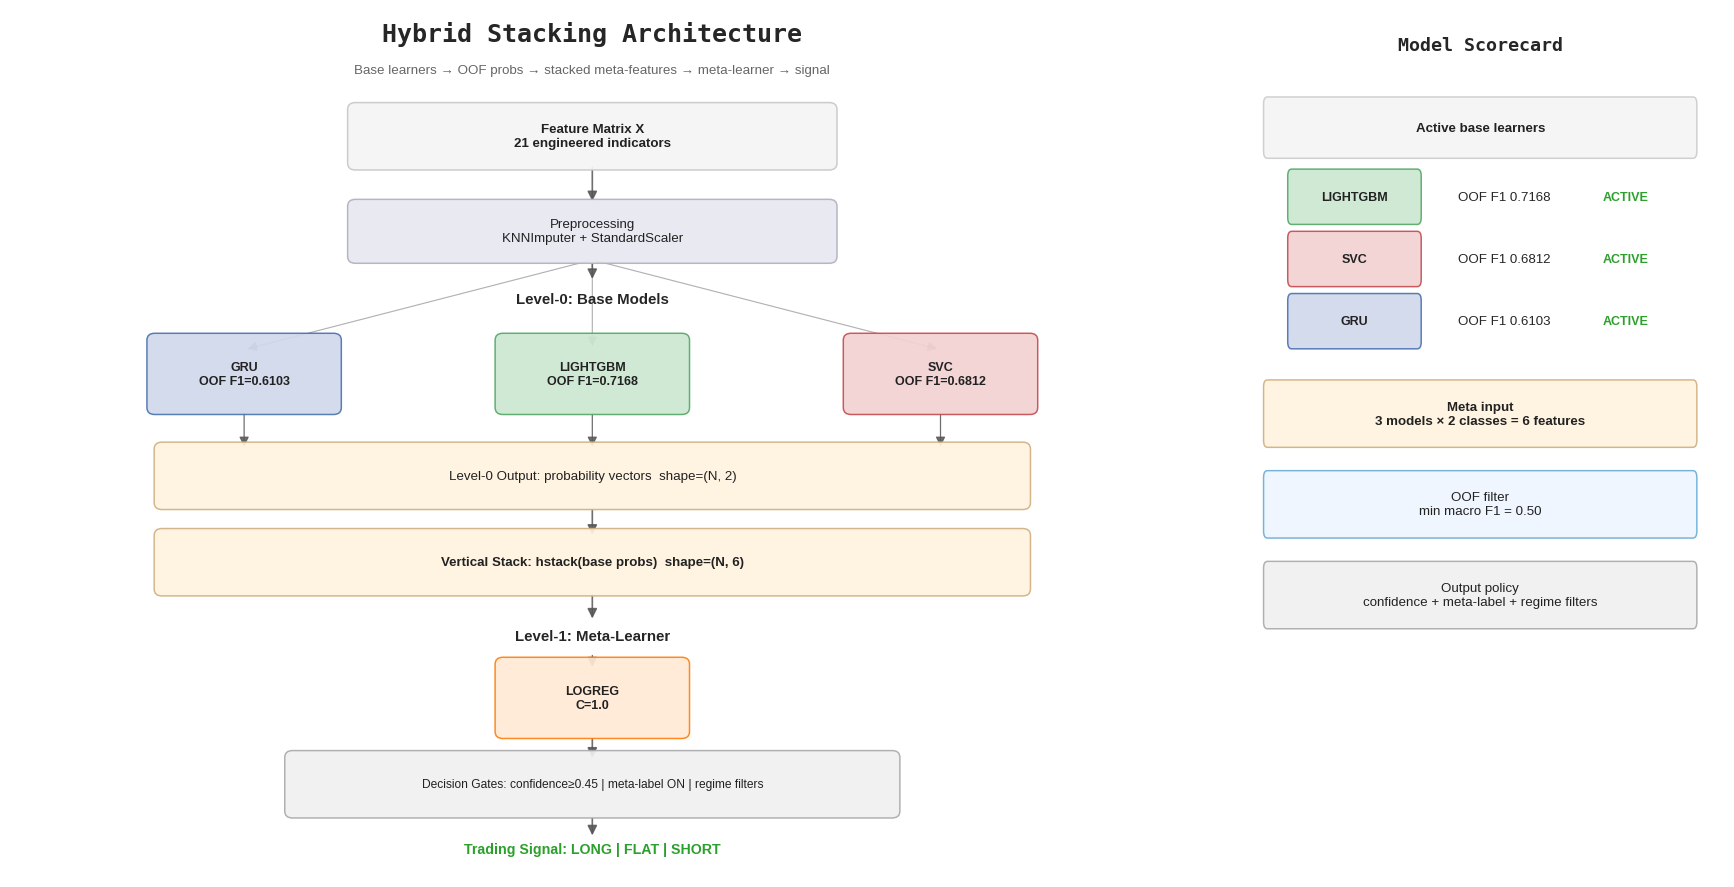

In [23]:
# Requires: §7 model, §3 features, §1 MIN_OOF_F1
n_active = len(model.active_model_names_)
N_CLASSES = 2
N_META_FEAT = n_active * N_CLASSES
MODEL_COLORS = {
    "gru": ("#4c72b0", "#d0d8eb"),
    "lightgbm": ("#55a868", "#cce8d2"),
    "svc": ("#c44e52", "#f2d2d3"),
}

def _box(ax, x, y, w, h, text, fc="#e8e8e8", ec="#aaaaaa", fs=8,
         fw="normal", color="#222222", alpha=0.92):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.08", fc=fc, ec=ec,
                                lw=0.9, alpha=alpha, zorder=2))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs,
            fontweight=fw, color=color, zorder=3)

def _arrow(ax, start, end, **kw):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>",
        mutation_scale=kw.pop("mutation_scale", 12),
        lw=kw.pop("lw", 1.0), color=kw.pop("color", "#555555"),
        alpha=kw.pop("alpha", 0.85),
        connectionstyle=kw.pop("connectionstyle", "arc3,rad=0.0"),
        zorder=1,
    ))

fig = _track(plt.figure(figsize=(15, 8)))
gs = fig.add_gridspec(1, 2, width_ratios=[2.4, 1], wspace=0.08)
ax = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# === Left: architecture flow ===
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.text(6, 9.65, "Hybrid Stacking Architecture", ha="center",
        fontsize=15, fontweight="bold", family="monospace")
ax.text(6, 9.28, "Base learners → OOF probs → stacked meta-features → meta-learner → signal",
        ha="center", fontsize=8, color="#666666")

_box(ax, 6, 8.55, 4.9, 0.62,
     f"Feature Matrix X\n{len(features)} engineered indicators",
     fc="#f5f5f5", ec="#c7c7c7", fw="bold")
_arrow(ax, (6, 8.23), (6, 7.76))
_box(ax, 6, 7.45, 4.9, 0.58, "Preprocessing\nKNNImputer + StandardScaler",
     fc="#e8e8f0", ec="#b0b0c0")
_arrow(ax, (6, 7.12), (6, 6.86))
ax.text(6, 6.62, "Level-0: Base Models", ha="center", fontsize=9, fontweight="bold")

base_cx = np.linspace(2.4, 9.6, max(n_active, 1))
for x, name in zip(base_cx, model.active_model_names_):
    ec, fc = MODEL_COLORS.get(name, ("#555555", "#eeeeee"))
    oof_f1 = model.oof_scores_.get(name, 0)
    _arrow(ax, (6, 7.12), (x, 6.08), lw=0.7, alpha=0.45)
    _box(ax, x, 5.8, 1.85, 0.78, f"{name.upper()}\nOOF F1={oof_f1:.4f}",
         fc=fc, ec=ec, fs=7.5, fw="bold")
    _arrow(ax, (x, 5.38), (x, 4.92), lw=0.75)

_box(ax, 6, 4.62, 8.9, 0.62,
     f"Level-0 Output: probability vectors  shape=(N, {N_CLASSES})",
     fc="#fff2e0", ec="#d0b080")
_arrow(ax, (6, 4.27), (6, 3.90))
_box(ax, 6, 3.62, 8.9, 0.62,
     f"Vertical Stack: hstack(base probs)  shape=(N, {N_META_FEAT})",
     fc="#fff2e0", ec="#d0b080", fw="bold")
_arrow(ax, (6, 3.28), (6, 2.93))
ax.text(6, 2.72, "Level-1: Meta-Learner", ha="center", fontsize=9, fontweight="bold")
_arrow(ax, (6, 2.58), (6, 2.37), lw=0.8)
_box(ax, 6, 2.05, 1.85, 0.78, "LOGREG\nC=1.0",
     fc="#ffead4", ec="#ff7f0e", fs=7.5, fw="bold")
_arrow(ax, (6, 1.62), (6, 1.32))
_box(ax, 6, 1.05, 6.2, 0.62,
     f"Decision Gates: confidence≥{model.confidence_threshold:.2f} | "
     f"meta-label {'ON' if model.use_meta_labeling else 'OFF'} | regime filters",
     fc="#f0f0f0", fs=7.2)
_arrow(ax, (6, 0.70), (6, 0.42))
ax.text(6, 0.25, "Trading Signal: LONG | FLAT | SHORT",
        ha="center", fontsize=8.5, fontweight="bold", color="#2ca02c")

# === Right: scorecard ===
ax2.axis("off")
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.text(5, 9.55, "Model Scorecard", ha="center",
         fontsize=11, fontweight="bold", family="monospace")
_box(ax2, 5, 8.65, 8.8, 0.55, "Active base learners",
     fc="#f5f5f5", ec="#cccccc", fw="bold")

score_rows = sorted(model.oof_scores_.items(), key=lambda kv: kv[1], reverse=True)
for i, (name, score) in enumerate(score_rows):
    y = 7.85 - i * 0.72
    status = "ACTIVE" if name in model.active_model_names_ else "FILTERED"
    ec, fc = MODEL_COLORS.get(name, ("#555555", "#eeeeee"))
    _box(ax2, 2.4, y, 2.6, 0.48, name.upper(), fc=fc, ec=ec, fs=7.5, fw="bold")
    ax2.text(5.5, y, f"OOF F1 {score:.4f}", ha="center", va="center", fontsize=8)
    ax2.text(8.0, y, status, ha="center", va="center", fontsize=7.5,
             color="#2ca02c" if status == "ACTIVE" else "#d62728", fontweight="bold")

info_y = 7.85 - len(score_rows) * 0.72 - 0.35
_box(ax2, 5, info_y, 8.8, 0.62,
     f"Meta input\n{n_active} models × {N_CLASSES} classes = {N_META_FEAT} features",
     fc="#fff2e0", ec="#d0b080", fw="bold")
_box(ax2, 5, info_y - 1.05, 8.8, 0.62,
     f"OOF filter\nmin macro F1 = {MIN_OOF_F1:.2f}",
     fc="#eef6ff", ec="#6baed6")
_box(ax2, 5, info_y - 2.10, 8.8, 0.62,
     "Output policy\nconfidence + meta-label + regime filters",
     fc="#f0f0f0", ec="#aaaaaa")

fig.subplots_adjust(left=0.03, right=0.98, top=0.94, bottom=0.04, wspace=0.08)
plt.show()

### 8.9 Base Learner Diversity & Meta-Learner Coefficients

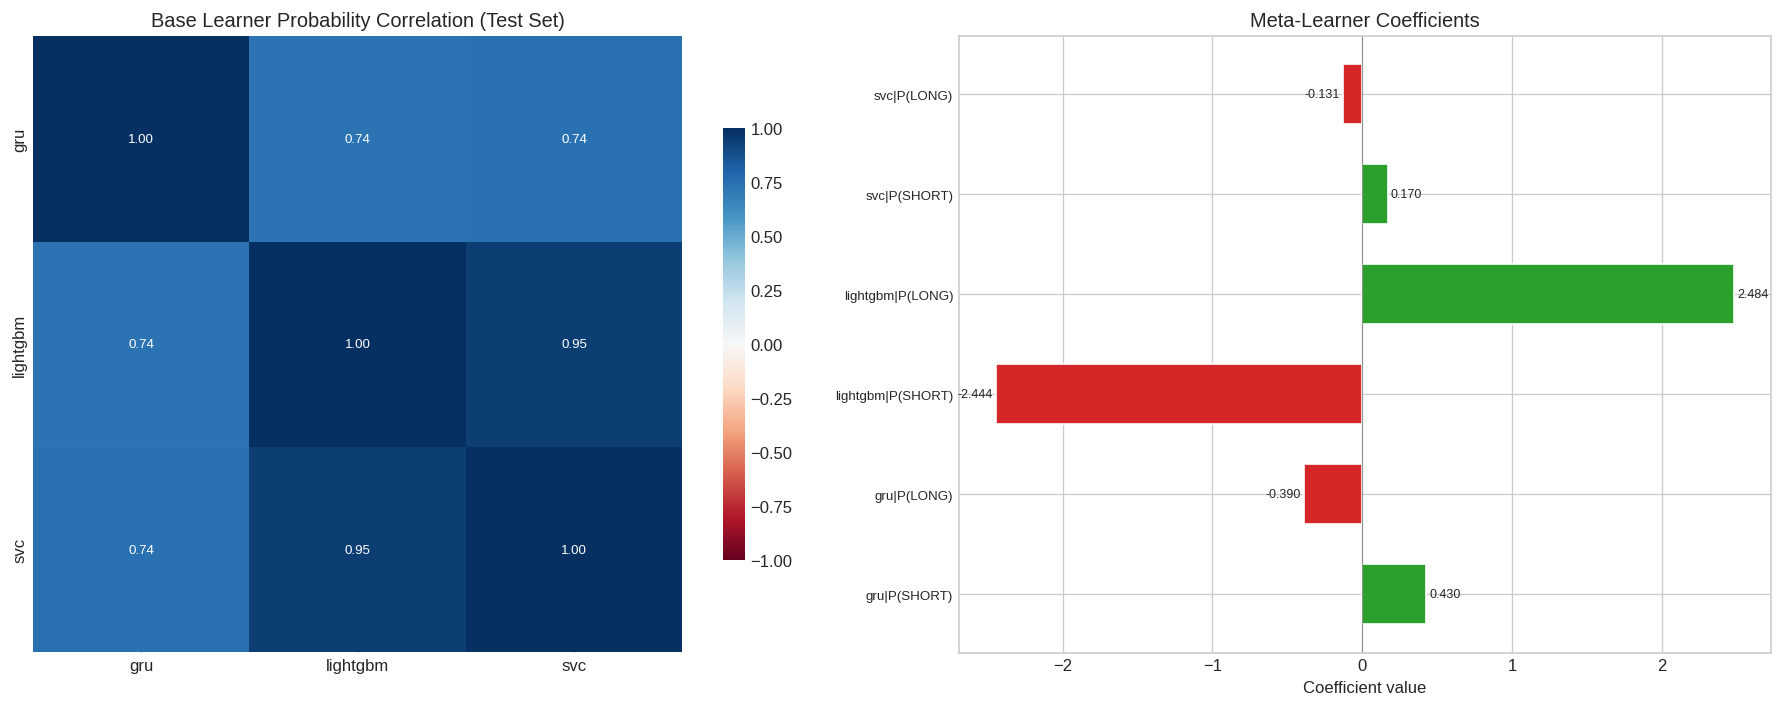

In [24]:
# Requires: §7 model, §3 test, features, §8.2 proba_labels, §1 LABELS, LABEL_NAMES
from src.models import derive_aligned_probabilities

test_X_pdf = test[features].to_pandas()
base_probs = {}
for name, m in model.active_models.items():
    try:
        base_probs[name] = derive_aligned_probabilities(m, test_X_pdf)[:, 1]
    except Exception:
        base_probs[name] = m.predict_proba(test_X_pdf)[:, 1]
base_df = pd.DataFrame(base_probs)
base_corr = base_df.corr()

meta_classes_enc = model.meta_model.classes_
meta_classes = model.label_encoder.inverse_transform(meta_classes_enc)
coefs = model.meta_model.coef_
feat_names = []
for nm in model.active_model_names_:
    for cls in meta_classes:
        feat_names.append(f'{nm}|P({LABEL_NAMES[int(cls)]})')

fig, axes = _track(plt.subplots(1, 2, figsize=(15, 6)))

sns.heatmap(base_corr, ax=axes[0], cmap='RdBu', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Base Learner Probability Correlation (Test Set)')

if coefs.shape[0] == 1:
    coef_vals = coefs[0]
    colors = ['#2ca02c' if v > 0 else '#d62728' for v in coef_vals]
    axes[1].barh(range(len(coef_vals)), coef_vals, color=colors,
                 edgecolor='white', height=0.6)
    for i, v in enumerate(coef_vals):
        axes[1].text(v + (0.02 if v >= 0 else -0.02), i, f'{v:.3f}',
                     va='center',
                     ha='left' if v >= 0 else 'right', fontsize=7.5)
    axes[1].set_yticks(range(len(feat_names)), feat_names, fontsize=8)
    axes[1].axvline(0, color='gray', lw=0.5)
    axes[1].set_title('Meta-Learner Coefficients')
    axes[1].set_xlabel('Coefficient value')
else:
    x = np.arange(len(feat_names))
    w = 0.8 / coefs.shape[0]
    for i, cls in enumerate(meta_classes):
        axes[1].bar(x + (i - coefs.shape[0] / 2 + 0.5) * w, coefs[i], w,
                    label=LABEL_NAMES[int(cls)], edgecolor='white')
    axes[1].set_xticks(x, feat_names, rotation=45, ha='right', fontsize=7)
    axes[1].axhline(0, color='gray', lw=0.5)
    axes[1].legend(fontsize=8)
    axes[1].set_title('Meta-Learner Coefficients')
    axes[1].set_ylabel('Coefficient value')

fig.tight_layout()
plt.show()

### 8.10 Ablation Study: Base Model Contribution

Train stacking ensemble with one base model removed at a time.

[ablation] Auto-tuning backtest params (§9 not yet run)...
  Tuning backtest: 676 combos ...
  Best: tp=9.00 sl=8.00 min_hold=16 sharpe=0.689 trades=467 pf=1.22
[ablation] Tuned: tp=9.0 sl=8.0 min_hold=16
[ablation] Full (GRU+LGBM+SVC): reused existing model
[ablation] Training No-GRU (LGBM+SVC) ...
[ablation] No-GRU (LGBM+SVC): done
[ablation] Training No-LGBM (GRU+SVC) ...
[ablation] No-LGBM (GRU+SVC): done
[ablation] Training No-SVC (GRU+LGBM) ...
[ablation] No-SVC (GRU+LGBM): done

=== Ablation Study Results ===
             Config  F1 Macro  Accuracy    AUC  Sharpe  Total Return  Max Drawdown
Full (GRU+LGBM+SVC)    0.7331    0.7343 0.8105 -0.3115       -0.0400       -0.2312
  No-GRU (LGBM+SVC)    0.7234    0.7239 0.8106 -1.0080       -0.1061       -0.2507
  No-LGBM (GRU+SVC)    0.7441    0.7460 0.7993 -0.5832       -0.0657       -0.2244
  No-SVC (GRU+LGBM)    0.7367    0.7381 0.8110 -0.2421       -0.0330       -0.2250


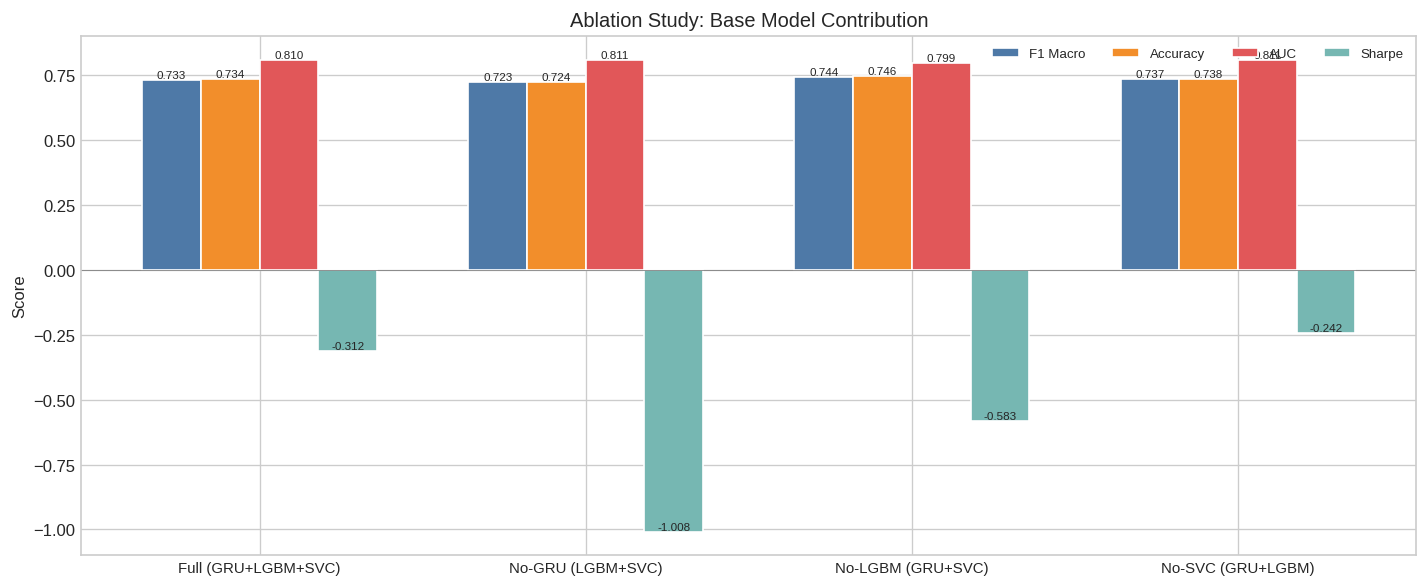

In [25]:
# Requires: §7 model, §8.2 y_true, predictions, pred_proba
# Auto-tunes backtest params if §9 not yet run
from src.models import assemble_base_model_registry

with _section("ablation_study"):
    # Ensure backtest params are available (tune if §9 not yet run)
    if 'tuned_min_hold' not in globals():
        print("[ablation] Auto-tuning backtest params (§9 not yet run)...")
        _abl_best = search_backtest_parameters(
            model, train, features, train["close"].to_numpy(),
            tp_range=TUNE_TP_RANGE_BT, sl_range=TUNE_SL_RANGE_BT,
            min_hold_values=TUNE_HOLD_VALUES,
        )
        backtest_tp = _abl_best["tp"]
        backtest_sl = _abl_best["sl"]
        tuned_min_hold = _abl_best["min_hold"]
        print(f"[ablation] Tuned: tp={backtest_tp:.1f} sl={backtest_sl:.1f} min_hold={tuned_min_hold}")

    full_registry = assemble_base_model_registry(RANDOM_STATE)
    ablation_configs = {
        "Full (GRU+LGBM+SVC)": None,
        "No-GRU (LGBM+SVC)": {k: v for k, v in full_registry.items() if k != "gru"},
        "No-LGBM (GRU+SVC)": {k: v for k, v in full_registry.items() if k != "lightgbm"},
        "No-SVC (GRU+LGBM)": {k: v for k, v in full_registry.items() if k != "svc"},
    }

    train_X_df = train[features]
    train_y_s = train["label"].to_pandas()
    train_event = train["event_end"].to_pandas() if "event_end" in train.columns else pd.Series([pd.NaT] * len(train))
    test_X_df = test[features]

    def _ablation_metrics(name, preds, proba=None):
        f1 = f1_score(y_true, preds, average="macro", zero_division=0)
        acc = accuracy_score(y_true, preds)
        if proba is not None and proba.shape[1] >= 2:
            y_bin = (y_true == LABELS[1]).astype(int)
            auc = roc_auc_score(y_bin, proba[:, 1]) if 0 < y_bin.sum() < len(y_bin) else 0.0
        else:
            auc = 0.0
        pos = enforce_minimum_position_hold(preds, tuned_min_hold)
        m, _, _ = run_barrier_backtest(test, pos, backtest_tp, backtest_sl)
        return {"Config": name, "F1 Macro": f1, "Accuracy": acc, "AUC": auc,
                "Sharpe": m["sharpe"], "Total Return": m["total_return"],
                "Max Drawdown": m["max_drawdown"]}

    ablation_rows = []
    for cfg_name, bm in ablation_configs.items():
        if bm is None:
            ablation_rows.append(_ablation_metrics(cfg_name, predictions, pred_proba))
            print(f"[ablation] {cfg_name}: reused existing model")
            continue
        print(f"[ablation] Training {cfg_name} ...")
        abl_model = HybridStackingSignalClassifier(
            random_state=RANDOM_STATE,
            base_models=bm,
        )
        abl_model.fit(train_X_df, train_y_s, train_event)
        abl_pred = abl_model.predict(test_X_df)
        abl_proba = abl_model.predict_proba(test_X_df)
        ablation_rows.append(_ablation_metrics(cfg_name, abl_pred, abl_proba))
        print(f"[ablation] {cfg_name}: done")

    abl_df = pd.DataFrame(ablation_rows)
    print("\n=== Ablation Study Results ===")
    print(abl_df.to_string(index=False, float_format="%.4f"))

    fig, ax = _track(plt.subplots(figsize=(12, 5)))
    metrics_plot = ["F1 Macro", "Accuracy", "AUC", "Sharpe"]
    x = np.arange(len(abl_df))
    width = 0.18
    colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]
    for j, met in enumerate(metrics_plot):
        vals = abl_df[met].values
        bars = ax.bar(x + j * width, vals, width, label=met, color=colors[j], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(abl_df["Config"], fontsize=9)
    ax.set_ylabel("Score")
    ax.set_title("Ablation Study: Base Model Contribution")
    ax.legend(fontsize=8, ncol=4, loc="upper right")
    ax.axhline(0, color="gray", lw=0.5)
    fig.tight_layout()
    plt.show()

    ablation_results = abl_df.to_dict(orient="records")

## 9. Position Strategy & Backtest Setup

In [26]:
# Requires: §7 model, §3 train, test, features, §1 tune params
if need('backtest'):
    with _section("backtesting"):
        best = search_backtest_parameters(
            model, train, features, train["close"].to_numpy(),
            tp_range=TUNE_TP_RANGE_BT, sl_range=TUNE_SL_RANGE_BT,
            min_hold_values=TUNE_HOLD_VALUES,
        )
        backtest_tp, backtest_sl = best["tp"], best["sl"]
        tuned_min_hold = best["min_hold"]
        raw_positions = model.predict_positions(
            test[features], close_prices=test["close"].to_numpy(),
            skip_min_hold=True,
        )
        positions = enforce_minimum_position_hold(raw_positions, tuned_min_hold)
        print(f"Tuned: tp={backtest_tp:.2f} sl={backtest_sl:.2f} "
              f"min_hold={tuned_min_hold} sharpe={best['score']:.3f}")

        metrics, executed_trades, equity_arr = run_barrier_backtest(
            test, positions, backtest_tp, backtest_sl,
        )
        # Override DSR with correct num_trials (matches CLI)
        from src.config import N_TUNING_TRIALS_APPROX
        from src.backtest import compute_deflated_sharpe_ratio
        dsr_stat, dsr_p = compute_deflated_sharpe_ratio(equity_arr, num_trials=N_TUNING_TRIALS_APPROX)
        metrics["dsr_statistic"] = dsr_stat
        metrics["dsr_p_value"] = dsr_p
        equity = pd.Series(equity_arr, index=test_pdf.index, name="equity")
        pnl_usd = np.diff(equity_arr, prepend=equity_arr[0])
        account_returns = np.diff(equity_arr) / equity_arr[:-1]
        account_returns = np.nan_to_num(account_returns, nan=0.0, posinf=0.0, neginf=0.0)
        account_returns = np.concatenate([[0.0], account_returns])
        bh_equity = (INITIAL_BALANCE * test_pdf["close"] / test_pdf["close"].iloc[0]).rename("bh_equity")
    NOTEBOOK_STATE['backtest'] = True

  Tuning backtest: 676 combos ...
  Best: tp=9.00 sl=8.00 min_hold=16 sharpe=0.689 trades=467 pf=1.22
Tuned: tp=9.00 sl=8.00 min_hold=16 sharpe=0.689


## 10. Backtest Results


### 10.1 Equity Curve, Drawdown, Positions

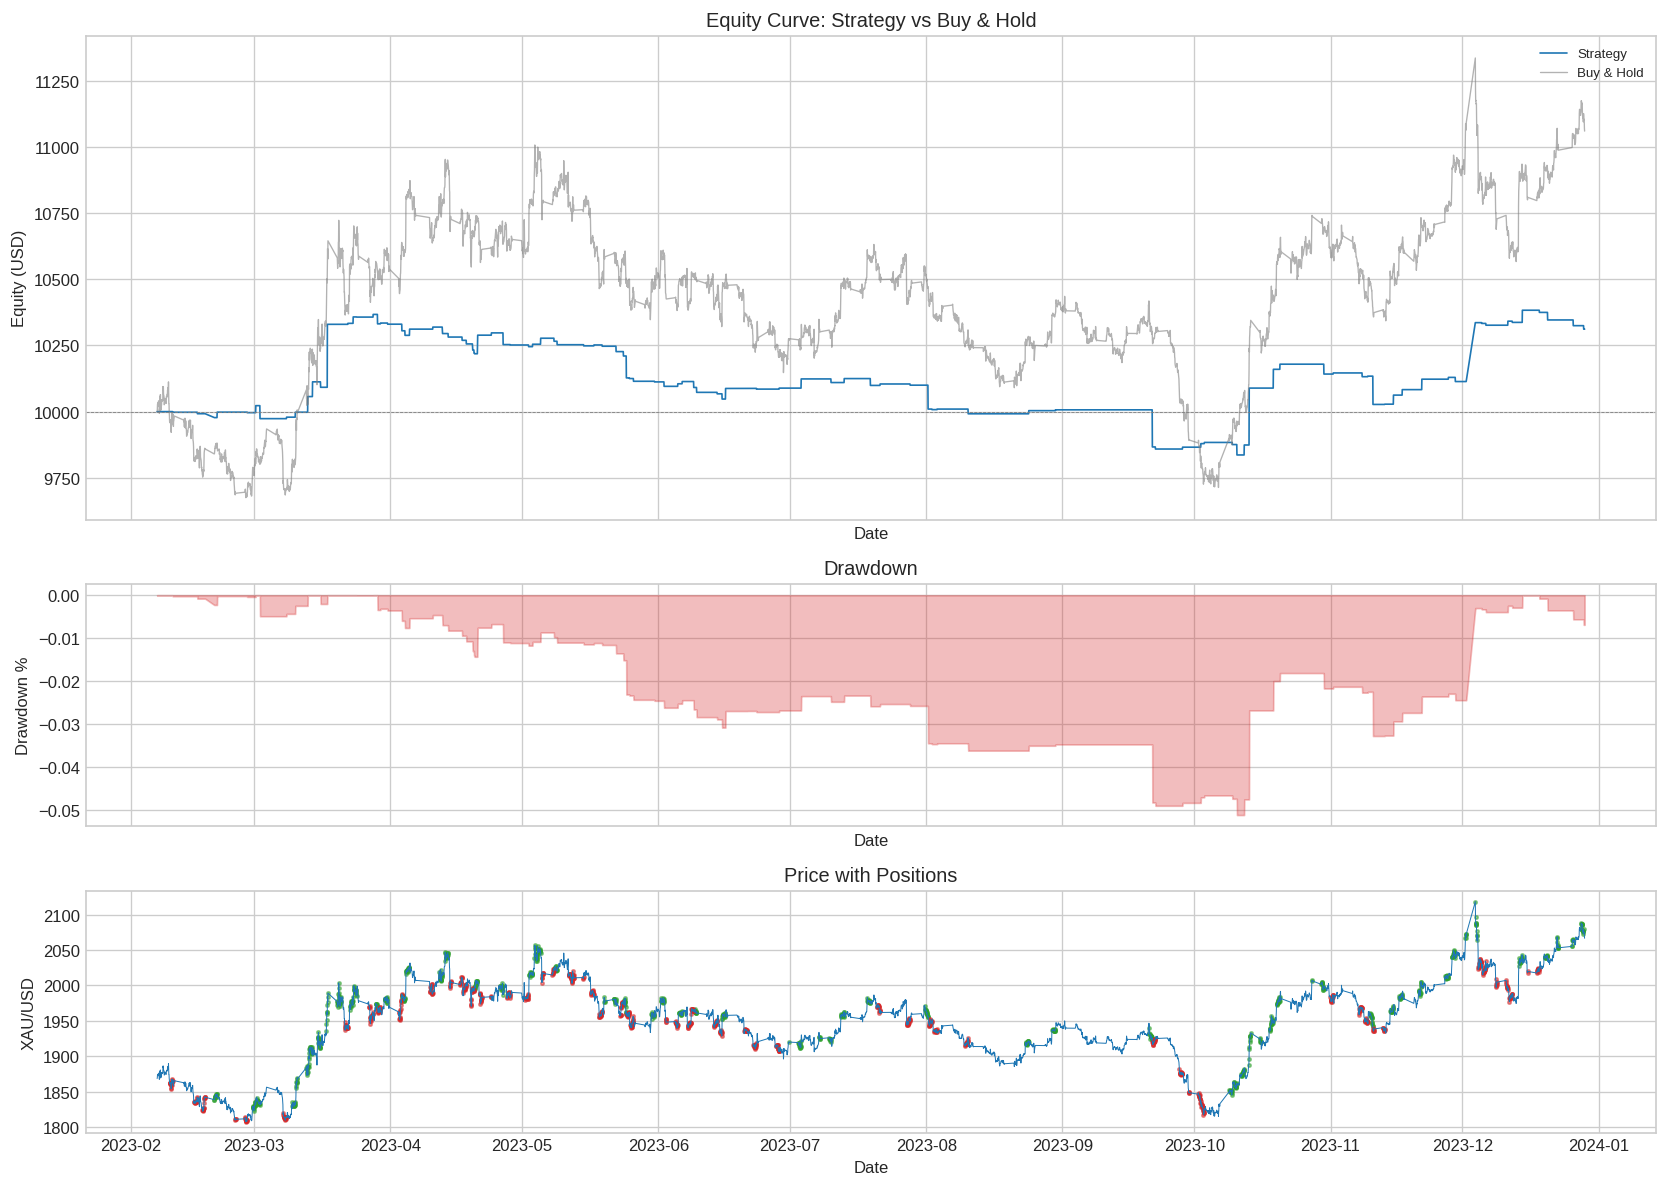

In [27]:
# Requires: §9 equity, bh_equity, positions, metrics, §3 test_pdf, §1 PALETTE
fig, axes = _track(plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                              height_ratios=[2, 1, 1]))

axes[0].plot(equity.index, equity.values, color="#1f77b4", lw=1, label="Strategy")
axes[0].plot(bh_equity.index, bh_equity.values, color="#7f7f7f", lw=0.8, alpha=0.6,
             label="Buy & Hold")
axes[0].axhline(INITIAL_BALANCE, color="gray", lw=0.5, ls="--")
axes[0].set_title("Equity Curve: Strategy vs Buy & Hold")
axes[0].set_ylabel("Equity (USD)")
axes[0].legend(fontsize=8)

drawdown = (equity - equity.cummax()) / equity.cummax()
axes[1].fill_between(equity.index, drawdown.values, 0, alpha=0.3, color="#d62728")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown %")

axes[2].plot(test_pdf.index, test_pdf["close"], color="#1f77b4", lw=0.6)
positions_series = pd.Series(positions, index=test_pdf.index)
for lv, color in PALETTE.items():
    mask = positions_series == lv
    axes[2].scatter(test_pdf.index[mask], test_pdf.loc[mask, "close"],
                    c=color, s=4, alpha=0.5)
axes[2].set_title("Price with Positions")
axes[2].set_ylabel("XAU/USD")

for ax in axes:
    ax.set_xlabel("Date")
fig.tight_layout()

### 10.2 PnL Analysis

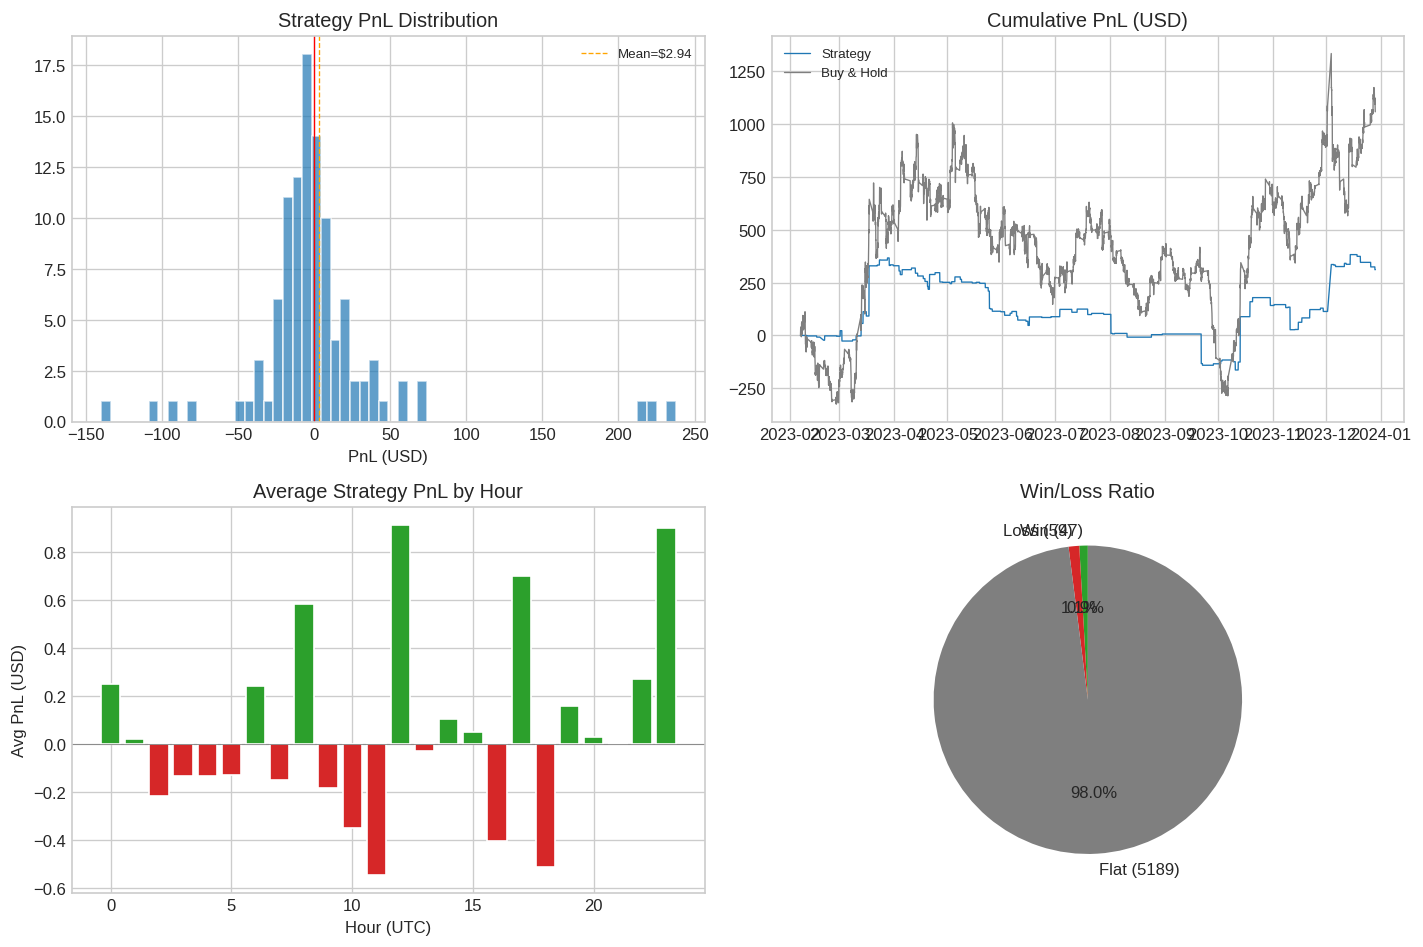

In [28]:
# Requires: §9 pnl_usd, equity, bh_equity, account_returns, §3 test_pdf, §1 INITIAL_BALANCE
fig, axes = _track(plt.subplots(2, 2, figsize=(12, 8)))

nonzero_pnl = pnl_usd[pnl_usd != 0]
mean_pnl = np.mean(nonzero_pnl) if len(nonzero_pnl) else 0.0
axes[0, 0].hist(nonzero_pnl, bins=60, color="#1f77b4", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(0, color="red", lw=0.8)
axes[0, 0].axvline(mean_pnl, color="orange", lw=0.8, ls="--", label=f"Mean=${mean_pnl:.2f}")
axes[0, 0].set_title("Strategy PnL Distribution")
axes[0, 0].set_xlabel("PnL (USD)")
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(test_pdf.index, equity - INITIAL_BALANCE, color="#1f77b4", lw=0.8,
                label="Strategy")
axes[0, 1].plot(test_pdf.index, bh_equity - INITIAL_BALANCE, color="#7f7f7f", lw=0.8,
                label="Buy & Hold")
axes[0, 1].set_title("Cumulative PnL (USD)")
axes[0, 1].legend(fontsize=8)

hourly = pd.DataFrame({"hour": test_pdf.index.hour, "pnl_usd": pnl_usd})
hourly_grouped = hourly.groupby("hour")["pnl_usd"].mean()
bar_colors = ["#2ca02c" if v > 0 else "#d62728" for v in hourly_grouped.values]
axes[1, 0].bar(hourly_grouped.index, hourly_grouped.values, color=bar_colors,
               edgecolor="white")
axes[1, 0].axhline(0, color="gray", lw=0.5)
axes[1, 0].set_title("Average Strategy PnL by Hour")
axes[1, 0].set_xlabel("Hour (UTC)")
axes[1, 0].set_ylabel("Avg PnL (USD)")

wins = (pnl_usd > 0).sum()
losses = (pnl_usd < 0).sum()
neutral = (pnl_usd == 0).sum()
axes[1, 1].pie(
    [wins, losses, neutral],
    labels=[f"Win ({wins})", f"Loss ({losses})", f"Flat ({neutral})"],
    colors=["#2ca02c", "#d62728", "#7f7f7f"],
    autopct="%.1f%%", startangle=90,
)
axes[1, 1].set_title("Win/Loss Ratio")

fig.tight_layout()
plt.show()

### 10.3 Trade Statistics Summary

In [29]:
# Trade statistics table for thesis
if 'executed_trades' in globals() and len(executed_trades) > 0:
    trades_df = pd.DataFrame(executed_trades)
    wins = trades_df[trades_df["win"] == True]
    losses = trades_df[trades_df["win"] == False]
    
    trade_stats = {
        "Metric": [
            "Total trades", "Winning trades", "Losing trades", "Win rate",
            "Avg PnL (USD)", "Avg win PnL (USD)", "Avg loss PnL (USD)",
            "Max win (USD)", "Max loss (USD)",
            "Avg bars held", "Avg win bars held", "Avg loss bars held",
            "Profit factor", "Long trades", "Short trades",
            "Avg cost per trade (USD)", "Avg swap per trade (USD)",
        ],
        "Value": [
            str(len(trades_df)),
            str(len(wins)),
            str(len(losses)),
            f"{len(wins)/len(trades_df):.2%}",
            f"${trades_df['trade_pnl_usd'].mean():.2f}",
            f"${wins['trade_pnl_usd'].mean():.2f}" if len(wins) > 0 else "N/A",
            f"${losses['trade_pnl_usd'].mean():.2f}" if len(losses) > 0 else "N/A",
            f"${trades_df['trade_pnl_usd'].max():.2f}",
            f"${trades_df['trade_pnl_usd'].min():.2f}",
            f"{trades_df['bars_held'].mean():.1f}",
            f"{wins['bars_held'].mean():.1f}" if len(wins) > 0 else "N/A",
            f"{losses['bars_held'].mean():.1f}" if len(losses) > 0 else "N/A",
            f"{metrics['profit_factor']:.4f}",
            str(len(trades_df[trades_df['direction'] == 'LONG'])),
            str(len(trades_df[trades_df['direction'] == 'SHORT'])),
            f"${metrics['avg_cost_usd']:.4f}",
            f"${metrics['avg_swap_usd']:.4f}",
        ],
    }
    trade_stats_df = pd.DataFrame(trade_stats)
    print("=== Bảng 5.x: Thống kê giao dịch ===")
    print(trade_stats_df.to_string(index=False))
else:
    print("Run §9 backtest first to generate trades.")

=== Bảng 5.x: Thống kê giao dịch ===
                  Metric    Value
            Total trades      106
          Winning trades       47
           Losing trades       59
                Win rate   44.34%
           Avg PnL (USD)    $2.94
       Avg win PnL (USD)   $31.99
      Avg loss PnL (USD)  $-20.21
           Max win (USD)  $237.70
          Max loss (USD) $-140.10
           Avg bars held     16.8
       Avg win bars held     17.0
      Avg loss bars held     16.7
           Profit factor   1.2610
             Long trades       56
            Short trades       50
Avg cost per trade (USD)  $1.0814
Avg swap per trade (USD) $-0.0207


### 10.4 Model Comparison: Baseline vs LightGBM vs Hybrid

Train LogReg + LightGBM standalone baselines, backtest all 3 models + B&H.

       Model     F1    Acc    AUC     AP Return Sharpe Sortino   MaxDD   PF   WinR Trades
  Buy & Hold      —      —      —      — 10.59%  0.951       — -11.75%    —      —      1
      LogReg 0.7480 0.7501 0.8162 0.7925 -5.79% -0.509  -0.283 -21.91% 0.91 21.84%    522
    LightGBM 0.7168 0.7226 0.8000 0.7789 -2.70% -0.224  -0.129 -20.46% 0.96 26.77%    594
Hybrid Stack 0.2433 0.2423 0.8105 0.7911  3.11%  0.689   0.144  -5.12% 1.26 44.34%    106


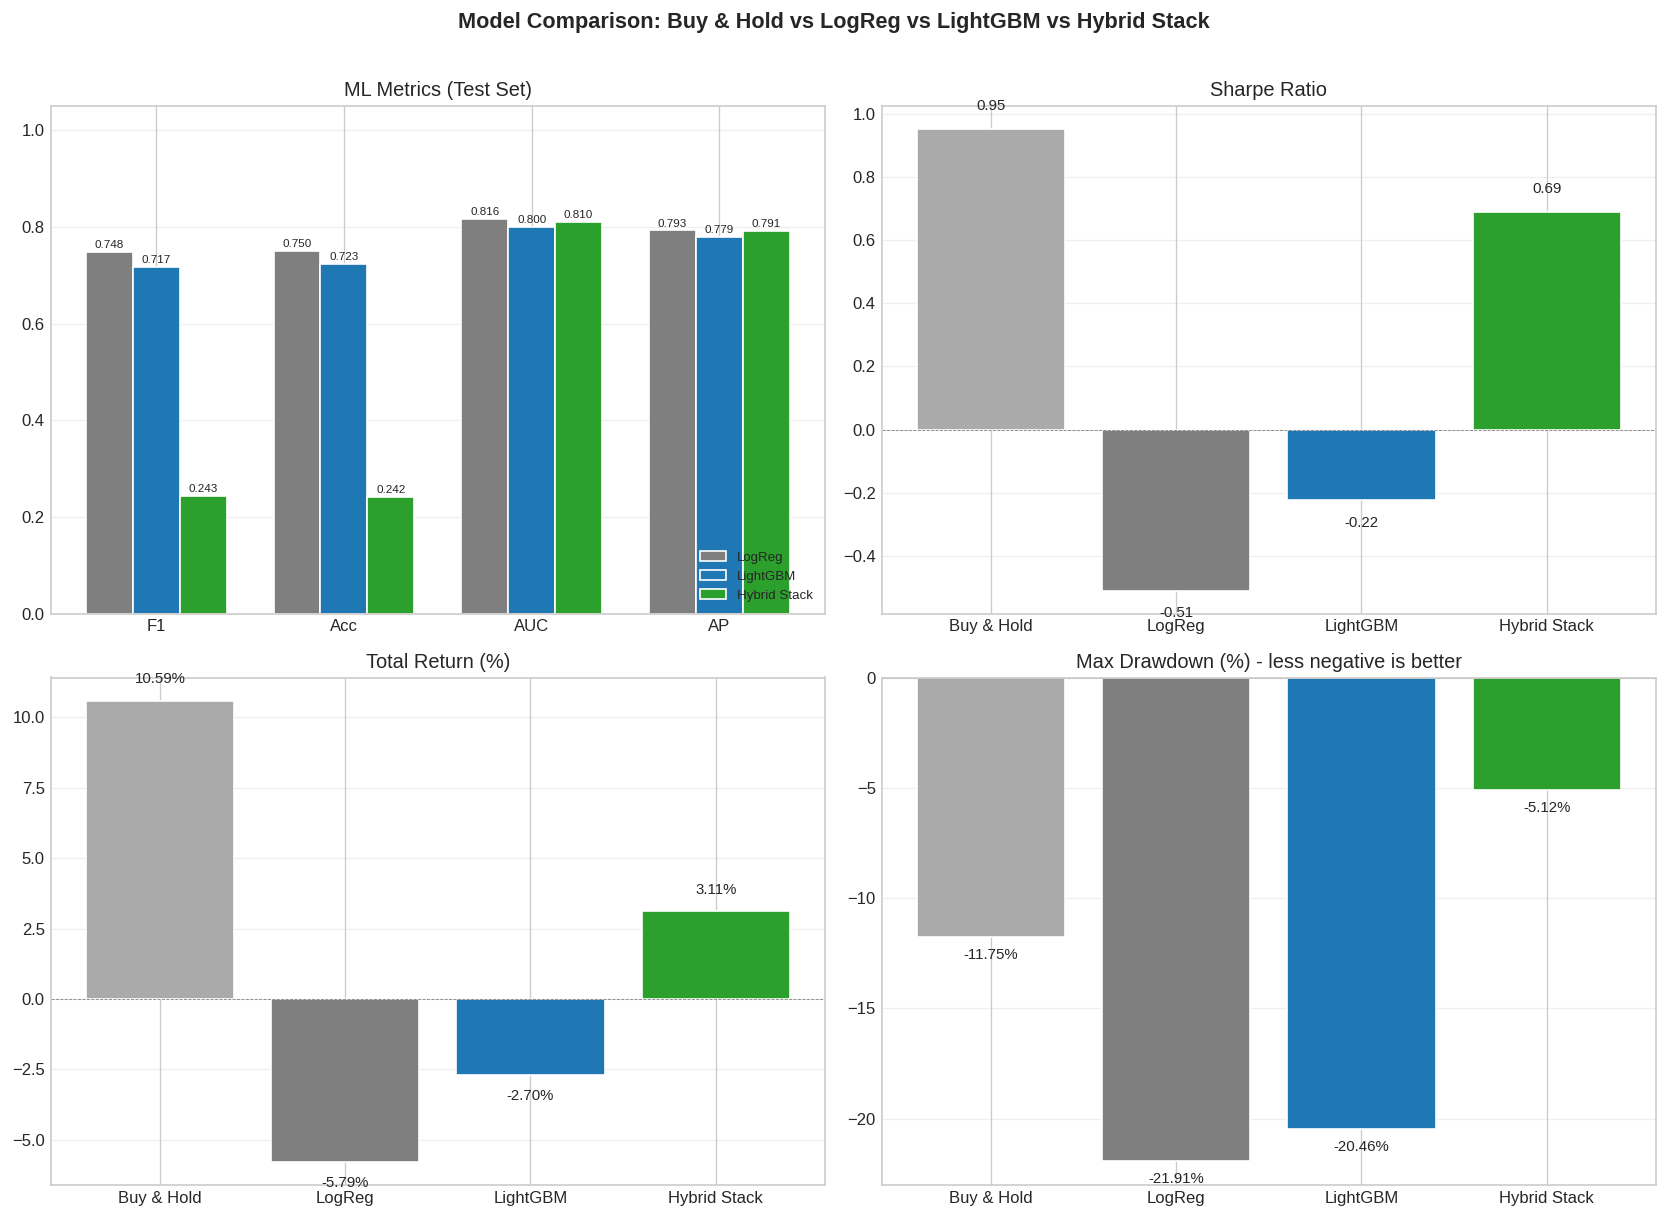

In [30]:
# Requires: §8.2 predictions, pred_proba, y_true, proba_labels, §9 backtest_tp, backtest_sl, tuned_min_hold,
#           account_returns, §3 train, test, features, test_pdf
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

train_X = train[features].to_pandas()
test_X = test[features].to_pandas()
train_y = train['label'].to_numpy()

with _section('baseline_training'):
    baseline_lr = make_pipeline(
        KNNImputer(n_neighbors=5), StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight='balanced',
                           random_state=RANDOM_STATE),
    )
    baseline_lr.fit(train_X, train_y)
    lr_pred = baseline_lr.predict(test_X)
    lr_proba = baseline_lr.predict_proba(test_X)

    baseline_lgb = LGBMClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1,
    )
    baseline_lgb.fit(train_X, train_y)
    lgb_pred = baseline_lgb.predict(test_X)
    lgb_proba = baseline_lgb.predict_proba(test_X)

def _multi_auc_ap(y_arr, proba, classes):
    aucs, aps = [], []
    for i, cls in enumerate(classes):
        y_b = (y_arr == cls).astype(int)
        if 0 < y_b.sum() < len(y_b):
            aucs.append(roc_auc_score(y_b, proba[:, i]))
            aps.append(average_precision_score(y_b, proba[:, i]))
    return float(np.mean(aucs)), float(np.mean(aps))

def _eval_row(name, pred, proba, classes):
    f1 = f1_score(y_true, pred, average='macro', zero_division=0)
    acc = accuracy_score(y_true, pred)
    auc, ap = _multi_auc_ap(y_true, proba, classes)
    pos = enforce_minimum_position_hold(pred, tuned_min_hold)
    m, _, _ = run_barrier_backtest(test, pos, backtest_tp, backtest_sl)
    return {
        'Model': name,
        'F1 Macro': f1, 'Accuracy': acc, 'AUC': auc, 'AP': ap,
        'Total Return': m['total_return'],
        'Sharpe': m['sharpe'],
        'Sortino': m['sortino'],
        'Max Drawdown': m['max_drawdown'],
        'Profit Factor': m['profit_factor'],
        'Win Rate': m['win_rate'],
        'Trades': int(m['trades']),
    }

rows = [_eval_row('LogReg', lr_pred, lr_proba, baseline_lr[-1].classes_)]
rows.append(_eval_row('LightGBM', lgb_pred, lgb_proba, baseline_lgb.classes_))
# Hybrid uses full predict_positions pipeline (same as §9)
hybrid_raw = model.predict_positions(test[features], close_prices=test["close"].to_numpy(), skip_min_hold=True)
hybrid_pos = enforce_minimum_position_hold(hybrid_raw, tuned_min_hold)
rows.append(_eval_row("Hybrid Stack", hybrid_pos, pred_proba,
                      np.array(proba_labels)))

# Buy & Hold row
bh_ret = test_pdf['close'].pct_change().fillna(0).to_numpy()
bh_cum = np.cumprod(1 + bh_ret)
bh_total = float(bh_cum[-1] - 1)
bh_peak = np.maximum.accumulate(bh_cum)
bh_dd = float(((bh_cum - bh_peak) / bh_peak).min())
bh_ann_vol = float(np.std(bh_ret) * ANN)
bh_sharpe = float((np.mean(bh_ret) * 24 * 252) / bh_ann_vol) if bh_ann_vol > 0 else 0.0
rows.insert(0, {
    'Model': 'Buy & Hold', 'F1 Macro': np.nan, 'Accuracy': np.nan,
    'AUC': np.nan, 'AP': np.nan,
    'Total Return': bh_total, 'Sharpe': bh_sharpe,
    'Sortino': np.nan,
    'Max Drawdown': bh_dd, 'Profit Factor': np.nan,
    'Win Rate': np.nan, 'Trades': 1,
})

compare_df = pd.DataFrame(rows)

def _f(v, fmt):
    return '—' if pd.isna(v) else format(v, fmt)

table_fmt = pd.DataFrame({
    'Model': compare_df['Model'],
    'F1': compare_df['F1 Macro'].map(lambda v: _f(v, '.4f')),
    'Acc': compare_df['Accuracy'].map(lambda v: _f(v, '.4f')),
    'AUC': compare_df['AUC'].map(lambda v: _f(v, '.4f')),
    'AP': compare_df['AP'].map(lambda v: _f(v, '.4f')),
    'Return': compare_df['Total Return'].map(lambda v: _f(v, '.2%')),
    'Sharpe': compare_df['Sharpe'].map(lambda v: _f(v, '.3f')),
    'Sortino': compare_df['Sortino'].map(lambda v: _f(v, '.3f')),
    'MaxDD': compare_df['Max Drawdown'].map(lambda v: _f(v, '.2%')),
    'PF': compare_df['Profit Factor'].map(lambda v: _f(v, '.2f')),
    'WinR': compare_df['Win Rate'].map(lambda v: _f(v, '.2%')),
    'Trades': compare_df['Trades'].astype(str),
})
print(table_fmt.to_string(index=False))

# --- Comparison charts ---
fig, axes = _track(plt.subplots(2, 2, figsize=(14, 10)))

ml_models = ['LogReg', 'LightGBM', 'Hybrid Stack']
ml_colors = ['#7f7f7f', '#1f77b4', '#2ca02c']
ml_keys = ['F1 Macro', 'Accuracy', 'AUC', 'AP']
ml_labels = ['F1', 'Acc', 'AUC', 'AP']
ml_data = {k: [next(r for r in rows if r['Model'] == n)[k] for n in ml_models]
           for k in ml_keys}

x = np.arange(len(ml_keys))
w = 0.25
for i, (name, color) in enumerate(zip(ml_models, ml_colors)):
    vals = [ml_data[k][i] for k in ml_keys]
    axes[0, 0].bar(x + (i - 1) * w, vals, w, label=name, color=color,
                   edgecolor='white')
    for j, v in enumerate(vals):
        axes[0, 0].text(x[j] + (i - 1) * w, v + 0.008, f'{v:.3f}',
                        ha='center', fontsize=7)
axes[0, 0].set_xticks(x, ml_labels)
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].set_title('ML Metrics (Test Set)')
axes[0, 0].legend(fontsize=8, loc='lower right')
axes[0, 0].grid(alpha=0.3, axis='y')

fin_models = ['Buy & Hold', 'LogReg', 'LightGBM', 'Hybrid Stack']
fin_colors = ['#aaaaaa', '#7f7f7f', '#1f77b4', '#2ca02c']

def _get(model, key):
    return next(r for r in rows if r['Model'] == model)[key]

sharpes = [_get(n, 'Sharpe') for n in fin_models]
bars = axes[0, 1].bar(fin_models, sharpes, color=fin_colors, edgecolor='white')
for b, v in zip(bars, sharpes):
    y_off = 0.05 if v >= 0 else -0.05
    axes[0, 1].text(b.get_x() + b.get_width() / 2, v + y_off,
                    f'{v:.2f}', ha='center',
                    va='bottom' if v >= 0 else 'top', fontsize=9)
axes[0, 1].axhline(0, color='gray', lw=0.5, ls='--')
axes[0, 1].set_title('Sharpe Ratio')
axes[0, 1].grid(alpha=0.3, axis='y')

returns = [_get(n, 'Total Return') * 100 for n in fin_models]
bars = axes[1, 0].bar(fin_models, returns, color=fin_colors, edgecolor='white')
for b, v in zip(bars, returns):
    y_off = 0.5 if v >= 0 else -0.5
    axes[1, 0].text(b.get_x() + b.get_width() / 2, v + y_off,
                    f'{v:.2f}%', ha='center',
                    va='bottom' if v >= 0 else 'top', fontsize=9)
axes[1, 0].axhline(0, color='gray', lw=0.5, ls='--')
axes[1, 0].set_title('Total Return (%)')
axes[1, 0].grid(alpha=0.3, axis='y')

drawdowns = [_get(n, 'Max Drawdown') * 100 for n in fin_models]
bars = axes[1, 1].bar(fin_models, drawdowns, color=fin_colors, edgecolor='white')
for b, v in zip(bars, drawdowns):
    axes[1, 1].text(b.get_x() + b.get_width() / 2, v - 0.5,
                    f'{v:.2f}%', ha='center', va='top', fontsize=9)
axes[1, 1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1, 1].set_title('Max Drawdown (%) - less negative is better')
axes[1, 1].grid(alpha=0.3, axis='y')

fig.suptitle('Model Comparison: Buy & Hold vs LogReg vs LightGBM vs Hybrid Stack',
             y=1.01, fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()
baseline_results = compare_df.to_dict(orient="records")

### 10.5 Statistical Significance: Bootstrap Sharpe Difference

Paired bootstrap (N=2000 iterations) on per-period returns.

Bootstrap Sharpe Difference (N=2000, paired IID resampling, annualized)
--------------------------------------------------------------------------------
  Hybrid - LightGBM     : delta=+1.028  95% CI [-1.691, +3.468]  P(diff>0)=78.0%  significant=NO
  Hybrid - LogReg       : delta=+1.325  95% CI [-1.453, +4.076]  P(diff>0)=82.5%  significant=NO
  LightGBM - LogReg     : delta=+0.297  95% CI [-2.123, +2.488]  P(diff>0)=59.4%  significant=NO


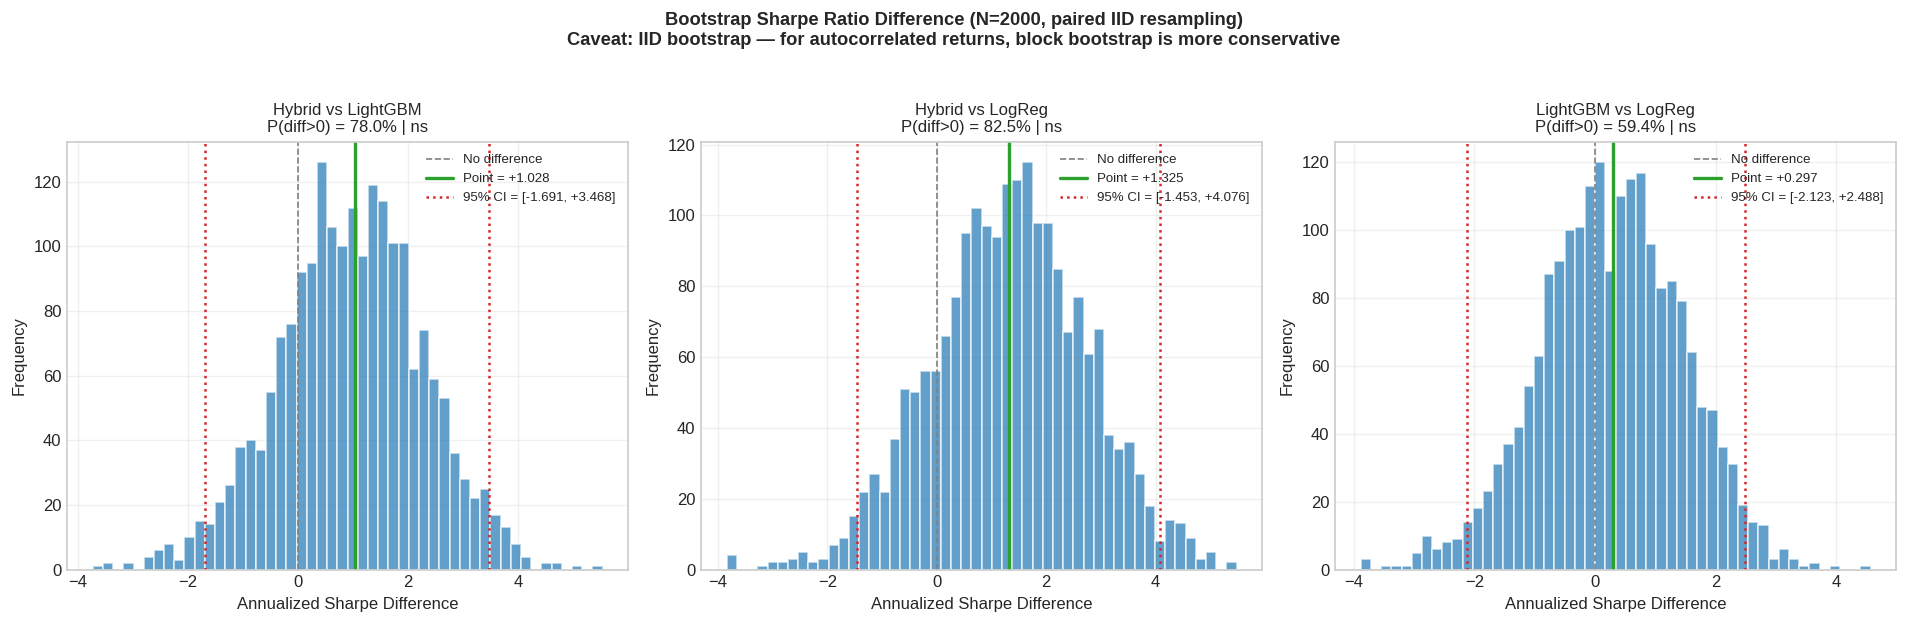

In [31]:
# Requires: §10.4 lr_pred, lgb_pred, §9 account_returns, backtest_tp, backtest_sl, tuned_min_hold
N_BOOT = 2000
rng_boot = np.random.default_rng(RANDOM_STATE)

def _build_rets(pred):
    pos = enforce_minimum_position_hold(pred, tuned_min_hold)
    _, _, eq = run_barrier_backtest(test, pos, backtest_tp, backtest_sl)
    r = np.diff(eq, prepend=eq[0])
    r = np.where(eq > 0, r / np.maximum(eq, 1e-12), 0.0)
    return np.nan_to_num(r, nan=0.0, posinf=0.0, neginf=0.0)

def _sharpe(r):
    s = np.std(r)
    return float(ANN * np.mean(r) / s) if s > 0 else 0.0

def _boot_diff(rets_a, rets_b, n_boot=N_BOOT):
    n = len(rets_a)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng_boot.integers(0, n, size=n)
        diffs[i] = _sharpe(rets_a[idx]) - _sharpe(rets_b[idx])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    point = _sharpe(rets_a) - _sharpe(rets_b)
    return {
        'point': point,
        'ci_low': float(lo), 'ci_high': float(hi),
        'p_positive': float((diffs > 0).mean()),
        'diffs': diffs,
    }

with _section('bootstrap_significance'):
    rets_lr_full = _build_rets(lr_pred)
    rets_lgb_full = _build_rets(lgb_pred)
    rets_hybrid_full = account_returns
    res_hl = _boot_diff(rets_hybrid_full, rets_lgb_full)
    res_hr = _boot_diff(rets_hybrid_full, rets_lr_full)
    res_ll = _boot_diff(rets_lgb_full, rets_lr_full)

def _sig(ci_lo, ci_hi):
    return 'YES' if (ci_lo > 0 or ci_hi < 0) else 'NO'

print(f'Bootstrap Sharpe Difference (N={N_BOOT}, paired IID resampling, annualized)')
print('-' * 80)
for name, res in [('Hybrid - LightGBM', res_hl),
                  ('Hybrid - LogReg', res_hr),
                  ('LightGBM - LogReg', res_ll)]:
    print(f'  {name:22s}: delta={res["point"]:+.3f}  '
          f'95% CI [{res["ci_low"]:+.3f}, {res["ci_high"]:+.3f}]  '
          f'P(diff>0)={res["p_positive"]:.1%}  '
          f'significant={_sig(res["ci_low"], res["ci_high"])}')

fig, axes = _track(plt.subplots(1, 3, figsize=(16, 5)))
panels = [
    ('Hybrid vs LightGBM', res_hl),
    ('Hybrid vs LogReg', res_hr),
    ('LightGBM vs LogReg', res_ll),
]

for ax, (title, res) in zip(axes, panels):
    ax.hist(res['diffs'], bins=50, color='#1f77b4', alpha=0.7,
            edgecolor='white')
    ax.axvline(0, color='gray', lw=1, ls='--', label='No difference')
    ax.axvline(res['point'], color='#2ca02c', lw=2,
               label=f'Point = {res["point"]:+.3f}')
    ax.axvline(res['ci_low'], color='#d62728', lw=1.5, ls=':',
               label=f'95% CI = [{res["ci_low"]:+.3f}, {res["ci_high"]:+.3f}]')
    ax.axvline(res['ci_high'], color='#d62728', lw=1.5, ls=':')
    sig_label = 'SIG' if (res['ci_low'] > 0 or res['ci_high'] < 0) else 'ns'
    ax.set_title(f'{title}\nP(diff>0) = {res["p_positive"]:.1%} | {sig_label}',
                 fontsize=10)
    ax.set_xlabel('Annualized Sharpe Difference')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(f'Bootstrap Sharpe Ratio Difference (N={N_BOOT}, paired IID resampling)\n'
             f'Caveat: IID bootstrap — for autocorrelated returns, block bootstrap is more conservative',
             y=1.03, fontsize=11, fontweight='bold')
fig.tight_layout()
plt.show()
bootstrap_results = {
    "n_iterations": N_BOOT,
    "comparisons": {
        "hybrid_vs_lgbm": {k: round(v, 6) if isinstance(v, float) else v for k, v in res_hl.items() if k != "diffs"},
        "hybrid_vs_lr": {k: round(v, 6) if isinstance(v, float) else v for k, v in res_hr.items() if k != "diffs"},
        "lgbm_vs_lr": {k: round(v, 6) if isinstance(v, float) else v for k, v in res_ll.items() if k != "diffs"},
    },
}

## 11. Robustness Analysis


### 11.1 Rolling Performance

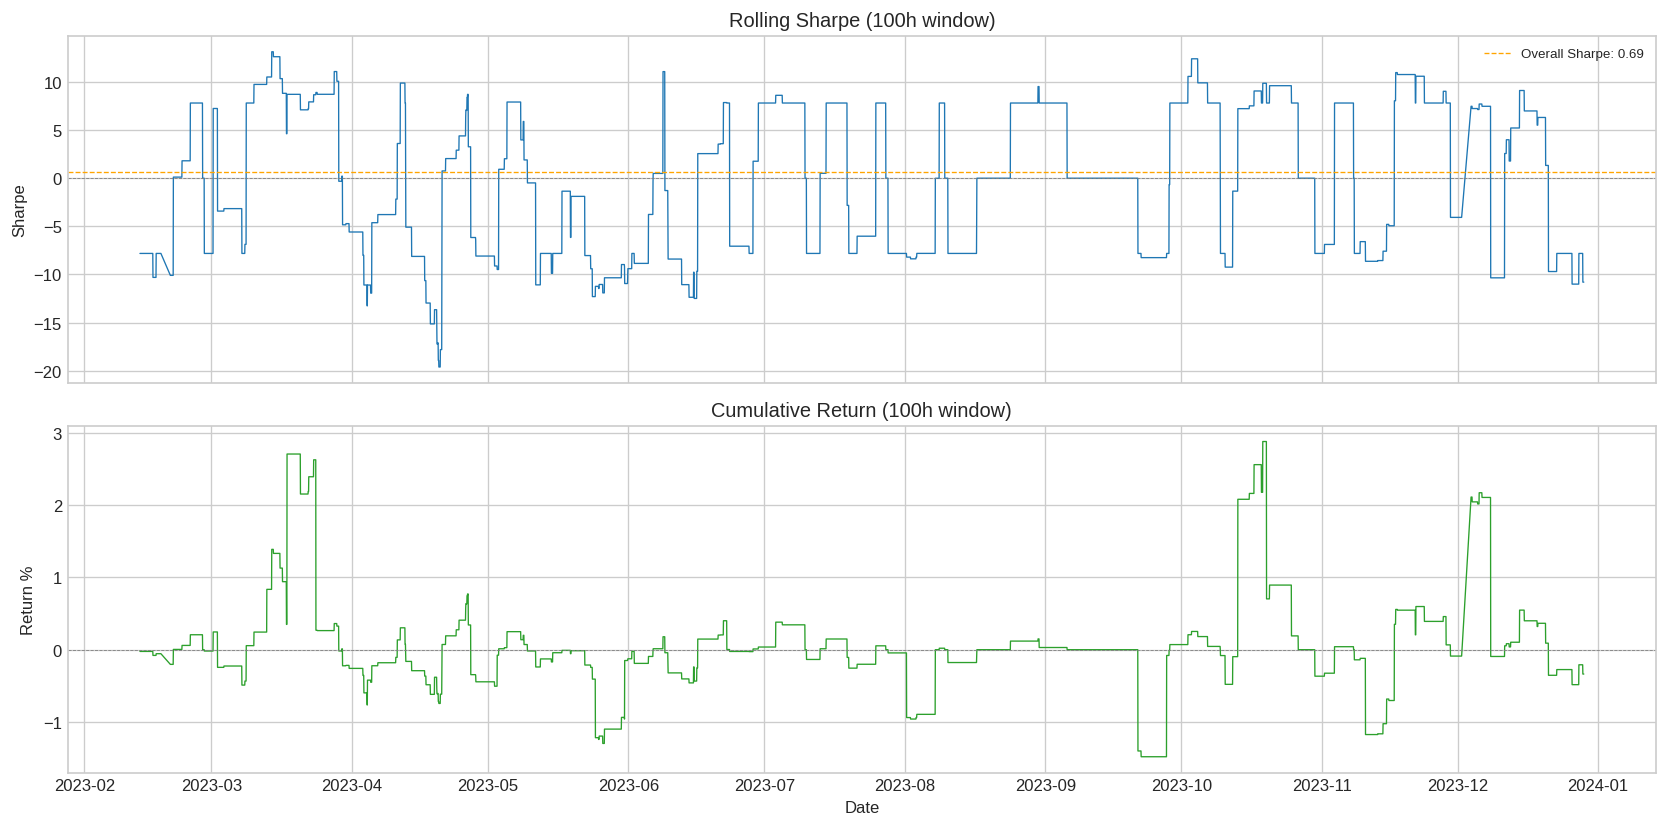

In [32]:
# Requires: §9 account_returns, metrics, equity_arr, §3 test_pdf
window = max(1, min(100, len(account_returns) // 3))

fig, axes = _track(plt.subplots(2, 1, figsize=(14, 7), sharex=True))

rolling_sharpe = pd.Series(account_returns).rolling(window).apply(
    lambda x: ANN * x.mean() / x.std() if x.std() > 0 else 0,
    raw=True,
)
axes[0].plot(test_pdf.index, rolling_sharpe.values, color="#1f77b4", lw=0.8)
axes[0].axhline(0, color="gray", lw=0.5, ls="--")
axes[0].axhline(metrics["sharpe"], color="orange", lw=0.8, ls="--",
                label=f"Overall Sharpe: {metrics['sharpe']:.2f}")
axes[0].set_title(f"Rolling Sharpe ({window}h window)")
axes[0].set_ylabel("Sharpe")
axes[0].legend(fontsize=8)

rolling_ret = pd.Series(account_returns).rolling(window).sum() * 100
axes[1].plot(test_pdf.index, rolling_ret.values, color="#2ca02c", lw=0.8)
axes[1].axhline(0, color="gray", lw=0.5, ls="--")
axes[1].set_title(f"Cumulative Return ({window}h window)")
axes[1].set_ylabel("Return %")
axes[1].set_xlabel("Date")

fig.tight_layout()
plt.show()

### 11.2 Walk-Forward Stability (Quarterly)

Slice test set into quarters, compute ML + financial metrics per slice.

Quarter  Samples  F1 Macro  Accuracy  Return %    Sharpe   Sortino   MaxDD %
 2023Q1      895  0.742467  0.744134  3.300737  3.262891  1.310338 -0.489341
 2023Q2     1468  0.694636  0.699591 -2.336503 -3.292312 -0.580227 -2.736061
 2023Q3     1491  0.773508  0.778001 -2.210146 -2.562875 -0.192878 -2.626754
 2023Q4     1441  0.716381  0.718251  4.515911  2.606557  0.688590 -1.493009


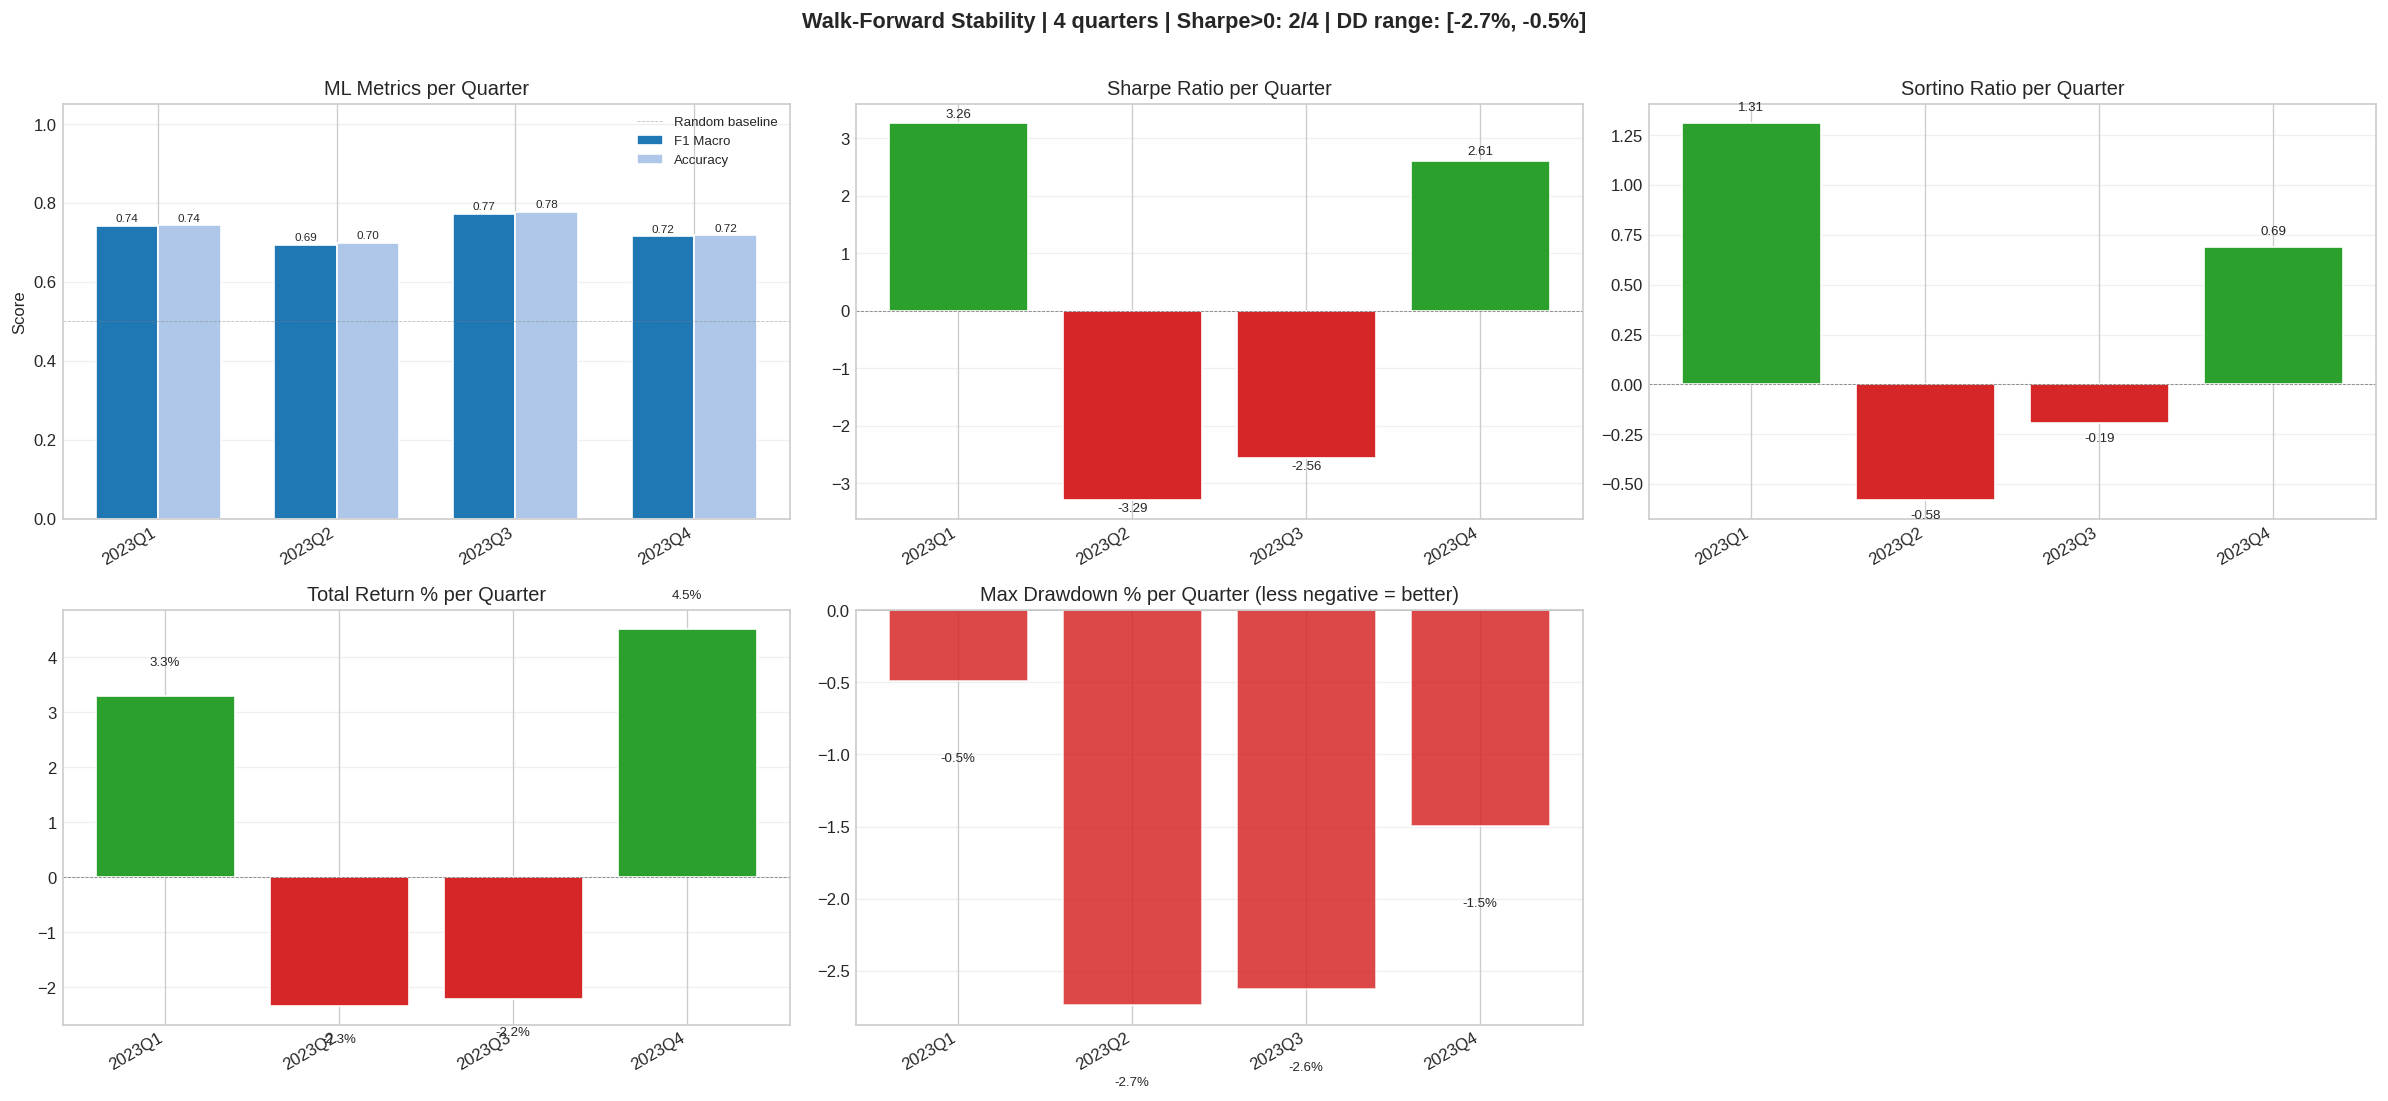

In [33]:
# Requires: §8.2 y_true, predictions, §9 positions, equity_arr, account_returns, §3 test_pdf
# FIX: separate if/else blocks for Sharpe and Sortino
quarter_keys = test_pdf.index.to_period('Q').astype(str)
wf_rows = []
for q in sorted(set(quarter_keys)):
    mask = (quarter_keys == q)
    if mask.sum() < 10:
        continue
    y_q = y_true[mask]
    pred_q = predictions[mask]
    f1_q = f1_score(y_q, pred_q, average='macro', zero_division=0)
    acc_q = accuracy_score(y_q, pred_q)
    ret_q = account_returns[mask]
    eq_q = equity_arr[mask]
    eq_norm = eq_q / eq_q[0] if eq_q[0] != 0 else eq_q
    peak_q = np.maximum.accumulate(eq_norm)
    dd_q = float(((eq_norm - peak_q) / peak_q).min()) if len(eq_norm) > 0 else 0.0
    ret_total_q = float(eq_q[-1] / eq_q[0] - 1) if len(eq_q) > 1 and eq_q[0] != 0 else 0.0

    # FIX: separate if/else for Sharpe
    if np.std(ret_q) > 0:
        sharpe_q = float(ANN * np.mean(ret_q) / np.std(ret_q))
    else:
        sharpe_q = 0.0

    # FIX: separate if/else for Sortino (downside deviation)
    downside_q = ret_q[ret_q < 0]
    if len(downside_q) > 0 and np.std(downside_q) > 0:
        sortino_q = float(ANN * np.mean(ret_q) / np.sqrt(np.mean(downside_q ** 2)))
    else:
        sortino_q = 0.0

    wf_rows.append({
        'Quarter': q, 'Samples': int(mask.sum()),
        'F1 Macro': f1_q, 'Accuracy': acc_q,
        'Return %': ret_total_q * 100, 'Sharpe': sharpe_q,
        'Sortino': sortino_q,
        'MaxDD %': dd_q * 100,
    })

wf_df = pd.DataFrame(wf_rows).sort_values('Quarter').reset_index(drop=True)
print(wf_df.to_string(index=False))

fig, axes = _track(plt.subplots(2, 3, figsize=(20, 9)))
quarters = wf_df['Quarter'].tolist()
x = np.arange(len(quarters))

w = 0.35
axes[0, 0].bar(x - w / 2, wf_df['F1 Macro'], w, label='F1 Macro',
               color='#1f77b4', edgecolor='white')
axes[0, 0].bar(x + w / 2, wf_df['Accuracy'], w, label='Accuracy',
               color='#aec7e8', edgecolor='white')
for i, (f1, acc) in enumerate(zip(wf_df['F1 Macro'], wf_df['Accuracy'])):
    axes[0, 0].text(i - w / 2, f1 + 0.01, f'{f1:.2f}', ha='center', fontsize=7)
    axes[0, 0].text(i + w / 2, acc + 0.01, f'{acc:.2f}', ha='center', fontsize=7)
axes[0, 0].set_xticks(x, quarters, rotation=30, ha='right')
axes[0, 0].axhline(0.5, color='gray', lw=0.5, ls='--', alpha=0.5,
                   label='Random baseline')
axes[0, 0].set_title('ML Metrics per Quarter')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3, axis='y')

sharpes = wf_df['Sharpe'].values
s_colors = ['#2ca02c' if v > 0 else '#d62728' for v in sharpes]
axes[0, 1].bar(x, sharpes, color=s_colors, edgecolor='white')
for i, v in enumerate(sharpes):
    y_off = 0.05 if v >= 0 else -0.05
    axes[0, 1].text(i, v + y_off, f'{v:.2f}', ha='center',
                    va='bottom' if v >= 0 else 'top', fontsize=8)
axes[0, 1].axhline(0, color='gray', lw=0.5, ls='--')
axes[0, 1].set_xticks(x, quarters, rotation=30, ha='right')
axes[0, 1].set_title('Sharpe Ratio per Quarter')
axes[0, 1].grid(alpha=0.3, axis='y')

sortinos = wf_df['Sortino'].values
so_colors = ['#2ca02c' if v > 0 else '#d62728' for v in sortinos]
axes[0, 2].bar(x, sortinos, color=so_colors, edgecolor='white')
for i, v in enumerate(sortinos):
    y_off = 0.05 if v >= 0 else -0.05
    axes[0, 2].text(i, v + y_off, f'{v:.2f}', ha='center',
                    va='bottom' if v >= 0 else 'top', fontsize=8)
axes[0, 2].axhline(0, color='gray', lw=0.5, ls='--')
axes[0, 2].set_xticks(x, quarters, rotation=30, ha='right')
axes[0, 2].set_title('Sortino Ratio per Quarter')
axes[0, 2].grid(alpha=0.3, axis='y')

returns = wf_df['Return %'].values
r_colors = ['#2ca02c' if v > 0 else '#d62728' for v in returns]
axes[1, 0].bar(x, returns, color=r_colors, edgecolor='white')
for i, v in enumerate(returns):
    y_off = 0.5 if v >= 0 else -0.5
    axes[1, 0].text(i, v + y_off, f'{v:.1f}%', ha='center',
                    va='bottom' if v >= 0 else 'top', fontsize=8)
axes[1, 0].axhline(0, color='gray', lw=0.5, ls='--')
axes[1, 0].set_xticks(x, quarters, rotation=30, ha='right')
axes[1, 0].set_title('Total Return % per Quarter')
axes[1, 0].grid(alpha=0.3, axis='y')

drawdowns = wf_df['MaxDD %'].values
axes[1, 1].bar(x, drawdowns, color='#d62728', edgecolor='white', alpha=0.85)
for i, v in enumerate(drawdowns):
    axes[1, 1].text(i, v - 0.5, f'{v:.1f}%', ha='center', va='top', fontsize=8)
axes[1, 1].axhline(0, color='gray', lw=0.5, ls='--')
axes[1, 1].set_xticks(x, quarters, rotation=30, ha='right')
axes[1, 1].set_title('Max Drawdown % per Quarter (less negative = better)')
axes[1, 1].grid(alpha=0.3, axis='y')

# Hide unused subplot
axes[1, 2].axis('off')

n_pos_sharpe = (wf_df['Sharpe'] > 0).sum()
n_q = len(wf_df)
worst_dd = wf_df['MaxDD %'].min()
best_dd = wf_df['MaxDD %'].max()
fig.suptitle(f'Walk-Forward Stability | {n_q} quarters | '
             f'Sharpe>0: {n_pos_sharpe}/{n_q} | '
             f'DD range: [{worst_dd:.1f}%, {best_dd:.1f}%]',
             y=1.01, fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## 12. Summary Dashboard

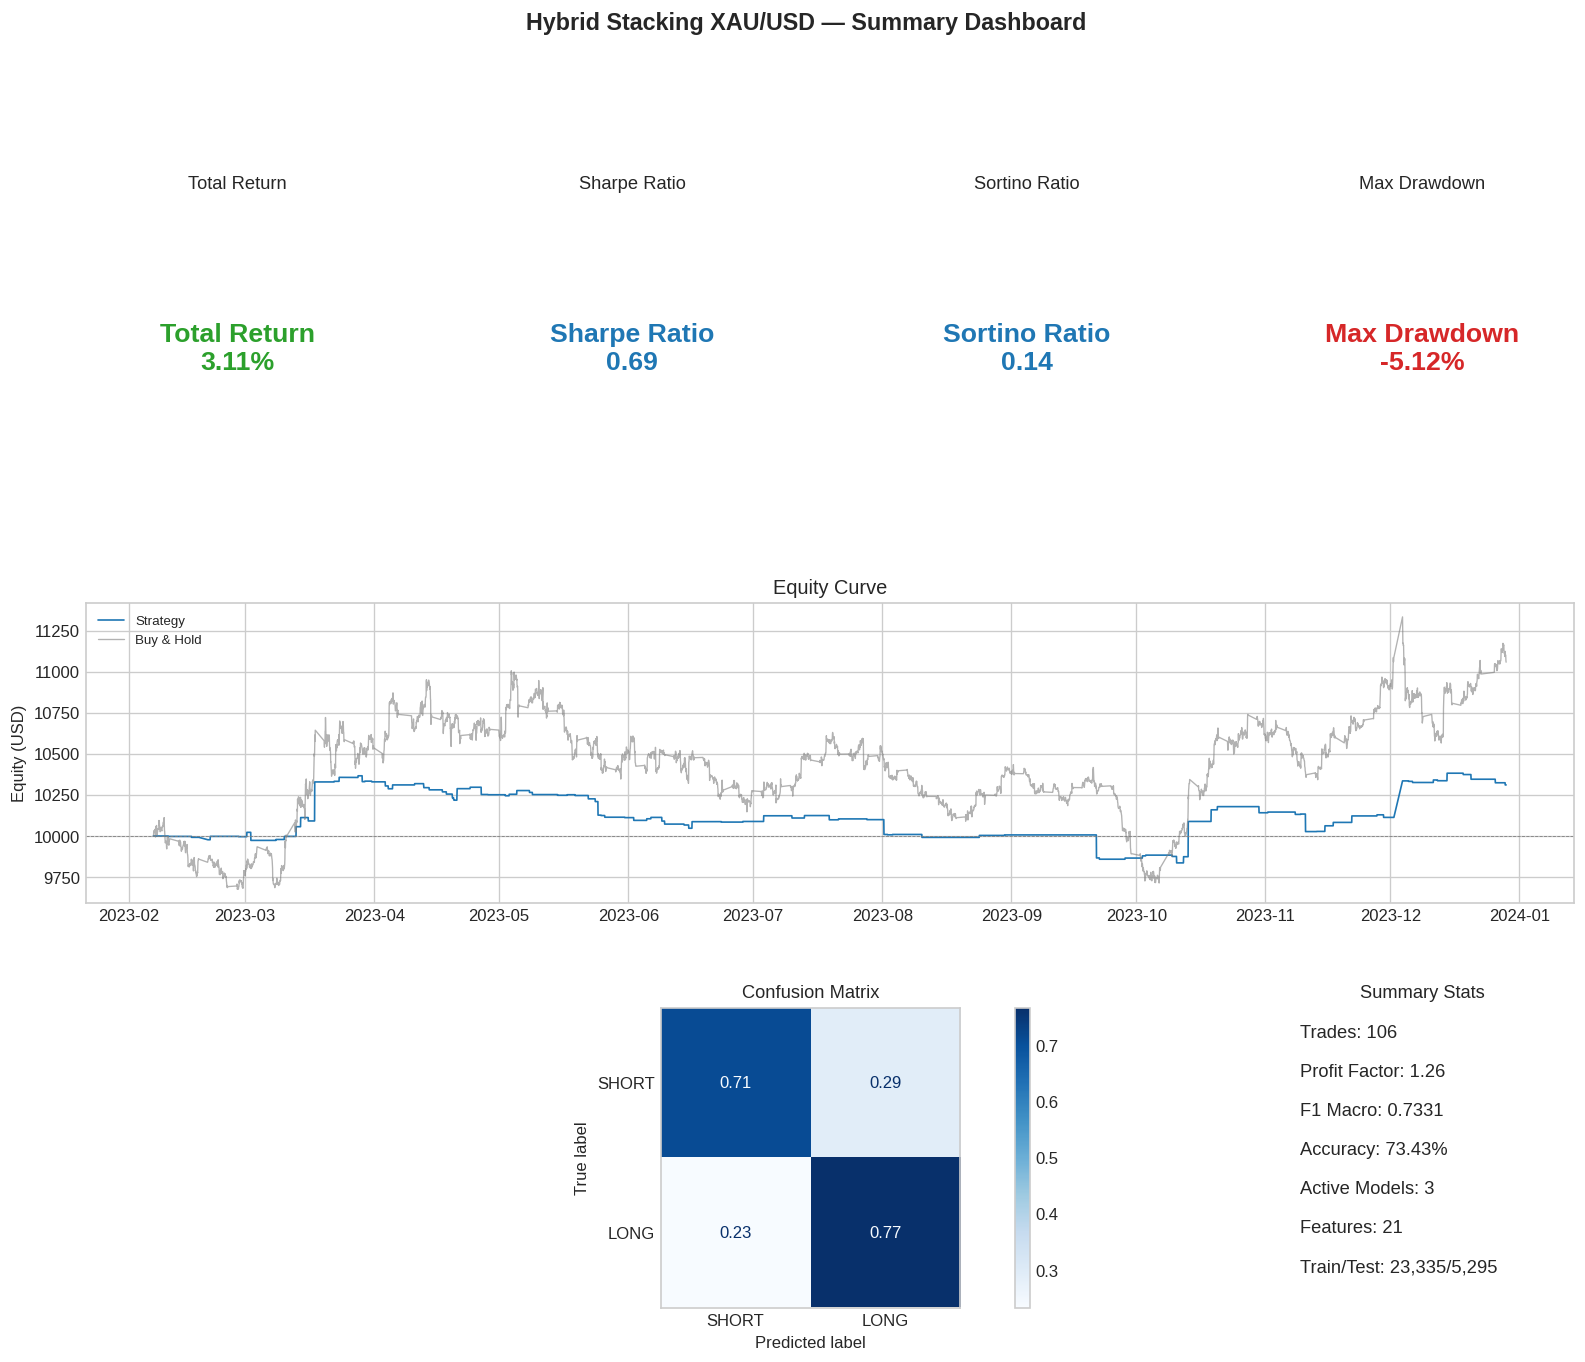

In [34]:
# Requires: §9 metrics, equity, bh_equity, §8.2 y_true, predictions, §7 model, §3 train, test, features
# FIX: separate _kpi() calls for each KPI (not merged)
fig = _track(plt.figure(figsize=(16, 12)))
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.3)

def _kpi(ax, title, value, color="#1f77b4"):
    ax.text(0.5, 0.5, value, ha="center", va="center", fontsize=16,
            fontweight="bold", color=color, transform=ax.transAxes)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

# FIX: separate _kpi() calls — one per KPI
_kpi(fig.add_subplot(gs[0, 0]), "Total Return",
     f"Total Return\n{metrics['total_return']:.2%}",
     "#2ca02c" if metrics["total_return"] > 0 else "#d62728")

_kpi(fig.add_subplot(gs[0, 1]), "Sharpe Ratio",
     f"Sharpe Ratio\n{metrics['sharpe']:.2f}")

_kpi(fig.add_subplot(gs[0, 2]), "Sortino Ratio",
     f"Sortino Ratio\n{metrics['sortino']:.2f}")

_kpi(fig.add_subplot(gs[0, 3]), "Max Drawdown",
     f"Max Drawdown\n{metrics['max_drawdown']:.2%}", "#d62728")

ax4 = fig.add_subplot(gs[1, :])
ax4.plot(equity.index, equity.values, color="#1f77b4", lw=1, label="Strategy")
ax4.plot(bh_equity.index, bh_equity.values, color="#7f7f7f", lw=0.8, alpha=0.6,
         label="Buy & Hold")
ax4.axhline(INITIAL_BALANCE, color="gray", lw=0.5, ls="--")
ax4.set_title("Equity Curve")
ax4.legend(fontsize=8)
ax4.set_ylabel("Equity (USD)")

ax5 = fig.add_subplot(gs[2, :3])
ConfusionMatrixDisplay.from_predictions(
    y_true, predictions, labels=LABEL_ORDER,
    display_labels=[LABEL_NAMES[k] for k in LABEL_ORDER],
    cmap="Blues", ax=ax5, normalize="true",
)
ax5.set_title("Confusion Matrix", fontsize=11)
ax5.grid(False)

ax6 = fig.add_subplot(gs[2, 3])
ax6.axis("off")
ax6.set_title("Summary Stats", fontsize=11)
lines = [
    f"Trades: {int(metrics['trades'])}",
    f"Profit Factor: {metrics['profit_factor']:.2f}",
    f"F1 Macro: {f1_score(y_true, predictions, average='macro', zero_division=0):.4f}",
    f"Accuracy: {accuracy_score(y_true, predictions):.2%}",
    f"Active Models: {len(model.active_model_names_)}",
    f"Features: {len(features)}",
    f"Train/Test: {len(train):,}/{len(test):,}",
]
for i, line in enumerate(lines):
    ax6.text(0.1, 0.9 - i * 0.13, line, transform=ax6.transAxes, fontsize=11)

fig.suptitle("Hybrid Stacking XAU/USD — Summary Dashboard",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## 13. Export Run Artifacts

In [35]:
# Requires: all prior sections
with _section("export"):
    config_payload = {
        "months": months_label, "data_range": file_range,
        "cv_splits": CV_SPLITS, "embargo_pct": EMBARGO_PCT, "purge_pct": PURGE_PCT,
        "fractional_d": FRACTIONAL_D, "tp_atr": tp_atr, "sl_atr": sl_atr,
        "tune_tp_range_bt": TUNE_TP_RANGE_BT, "tune_sl_range_bt": TUNE_SL_RANGE_BT,
        "tune_hold_values": TUNE_HOLD_VALUES,
        "labeling_horizon": LABELING_HORIZON, "swing_window": SWING_WINDOW,
        "tune_tp_range": TUNE_TP_RANGE, "tune_sl_range": TUNE_SL_RANGE,
        "tune_target_balance": TUNE_TARGET_BALANCE, "min_oof_f1": MIN_OOF_F1,
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "use_meta_labeling": USE_META_LABELING,
        "meta_label_threshold": META_LABEL_THRESHOLD,
        "short_meta_label_threshold": SHORT_META_LABEL_THRESHOLD,
        "long_only": config.long_only,
        "trend_filter_enabled": TREND_FILTER_ENABLED,
        "trend_ema_period": TREND_EMA_PERIOD,
        "adx_threshold": ADX_THRESHOLD,
        "random_state": RANDOM_STATE,
        "timeframe": config.timeframe,
        "initial_balance": INITIAL_BALANCE,
    }
    run_dir = REPORT_DIR / f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    run_dir.mkdir(parents=True, exist_ok=True)

    outputs = PipelineOutputs(
        train=train, test=test, features=features, model=model,
        predictions=predictions, positions=positions,
        backtest_metrics=metrics, equity=equity_arr,
        executed_trades=executed_trades,
        pred_proba=model.predict_proba(test[features]),
    )
    save_run_artifacts(run_dir=run_dir, outputs=outputs,
                          config_payload=config_payload)

    figures_dir = run_dir / "figures"
    figures_dir.mkdir(exist_ok=True)
    FIGURE_NAMES = [
        "label_distribution", "fracdiff_comparison", "adf_stationarity",
        "technical_indicators",
        "feature_correlation", "feature_distributions_by_label", "cv_splits",
        "learning_curve",
        "oof_scores", "test_evaluation", "confusion_matrix",
        "classification_diagnostics", "prediction_accuracy_map",
        "feature_importance", "shap_beeswarm", "shap_bar",
        "model_architecture", "base_learner_diversity",
        "ablation_study",
        "equity_drawdown_positions", "pnl_analysis",
        "model_comparison",
        "bootstrap_significance",
        "rolling_performance",
        "walk_forward_quarterly",
        "summary_dashboard",
    ]
    for fig, name in zip(_figures, FIGURE_NAMES):
        fig.savefig(figures_dir / f"{name}.png", dpi=160, bbox_inches="tight")

    run_data_path = run_dir / "run_data.json"
    run_data = json.loads(run_data_path.read_text())
    run_data["reproducibility"]["run_entrypoint"] = "notebook"
    _timings["total"] = time.perf_counter() - _t0
    run_data["timing"] = {k: round(v, 4) for k, v in _timings.items()}

    # --- Enrich run_data with notebook-only results ---

    # 3 missing config fields
    run_data["config"]["leverage"] = LEVERAGE
    run_data["config"]["contract_size"] = CONTRACT_SIZE
    run_data["config"]["bb_width_min_mult"] = BB_WIDTH_MIN_MULT

    # Tuned backtest params
    run_data["backtest"]["tuned_tp"] = backtest_tp
    run_data["backtest"]["tuned_sl"] = backtest_sl
    run_data["backtest"]["tuned_min_hold"] = tuned_min_hold

    # SHAP mean values
    if 'shap_mean_values' in globals():
        run_data["shap_mean_values"] = shap_mean_values

    # Ablation results
    if 'ablation_results' in globals():
        run_data["ablation"] = ablation_results

    # Baseline comparison
    if 'baseline_results' in globals():
        run_data["baseline_comparison"] = baseline_results

    # Bootstrap significance
    if 'bootstrap_results' in globals():
        run_data["bootstrap_significance"] = bootstrap_results
    run_data_path.write_text(json.dumps(run_data, indent=2, ensure_ascii=False))

    print(f"Run saved to: {run_dir}")
    print(f"Files: {len(_figures)} figures + predictions/trades/metrics/importance/run_data")
    print("\n=== PIPELINE TIMING ===")
    for step, elapsed in sorted(_timings.items(), key=lambda x: x[1], reverse=True):
        print(f"  {step}: {elapsed:.4f}s")
    print(f"  TOTAL: {_timings['total']:.4f}s")


Run dir: /home/ultimatebrok/Downloads/thesis-compact/reports/run_20260603_181525
Files: tables/predictions.csv, tables/trades.csv (106 trades), tables/backtest_metrics.csv, tables/feature_importance.csv, run_data.json, figures/*.png
Run saved to: reports/run_20260603_181525
Files: 25 figures + predictions/trades/metrics/importance/run_data

=== PIPELINE TIMING ===
  total: 1221.5980s
  ablation_study: 726.2978s
  model_training: 375.0064s
  backtesting: 30.4178s
  data_loading: 20.4665s
  shap_analysis: 1.0094s
  bootstrap_significance: 0.3118s
  baseline_training: 0.1378s
  TOTAL: 1221.5980s


## 14. Export Tables for Report

Exported CSV files:
- `data_statistics.csv` — row counts, date ranges, label distribution
- `feature_description.csv` — feature names, types, descriptions
- `hyperparameters.csv` — model hyperparameters and training config
- `trade_statistics.csv` — PnL, win rate, holding period, direction breakdown
- `feature_importance.csv` — ranked LightGBM feature importance
- `per_class_metrics.csv` — precision, recall, F1 per class (from `run_data.json`)
- `roc_auc.csv` — ROC AUC score (from `run_data.json`)


In [36]:
# Export all report tables to CSV for thesis
import os
table_dir = run_dir / "tables"
table_dir.mkdir(parents=True, exist_ok=True)

exports = {}
if 'data_stats_df' in globals():
    exports["data_statistics.csv"] = data_stats_df
if 'feat_desc' in globals():
    exports["feature_description.csv"] = feat_desc
if 'hp_df' in globals():
    exports["hyperparameters.csv"] = hp_df
if 'trade_stats_df' in globals():
    exports["trade_statistics.csv"] = trade_stats_df

# feature_importance.csv already saved by save_run_artifacts in §13

for fname, df in exports.items():
    path = table_dir / fname
    df.to_csv(path, index=False)
    print(f"  Saved: {path}")


# Export evaluation metrics from run_data
run_data_path = run_dir / "run_data.json"
if run_data_path.exists():
    rd = json.loads(run_data_path.read_text())
    # Per-class metrics table
    pcm = rd.get("evaluation", {}).get("per_class_metrics", {})
    if pcm:
        pcm_rows = []
        for label, metrics in pcm.items():
            pcm_rows.append({"label": label, **metrics})
        pcm_df = pd.DataFrame(pcm_rows)
        pcm_df.to_csv(table_dir / "per_class_metrics.csv", index=False)
        print(f"  Saved: {table_dir / 'per_class_metrics.csv'}")

    # ROC AUC
    roc = rd.get("evaluation", {}).get("roc_auc")
    if roc is not None:
        pd.DataFrame([{"metric": "roc_auc", "value": roc}]).to_csv(
            table_dir / "roc_auc.csv", index=False)
        print(f"  Saved: {table_dir / 'roc_auc.csv'}")
# Count all exported files
all_tables = list(table_dir.glob("*.csv"))
print(f"\nExported {len(all_tables)} tables to {table_dir}/")

  Saved: reports/run_20260603_181525/tables/data_statistics.csv
  Saved: reports/run_20260603_181525/tables/feature_description.csv
  Saved: reports/run_20260603_181525/tables/hyperparameters.csv
  Saved: reports/run_20260603_181525/tables/trade_statistics.csv
  Saved: reports/run_20260603_181525/tables/per_class_metrics.csv
  Saved: reports/run_20260603_181525/tables/roc_auc.csv

Exported 10 tables to reports/run_20260603_181525/tables/
